# Продажи топлива по регионам

Регион определяется по `kladr_code` регистрации клиента, а не по адресу АЗС: региона заправки в данных нет. Для продаж используются очищенные физический объём и выручка, поэтому полные отмены и отрицательные операции не учитываются как продажи.

In [22]:
from pathlib import Path
import pandas as pd

OUTPUT_DIR = Path("data/processed")
REGION_NAMES = {
    "77": "Москва", "50": "Московская область",
    "78": "Санкт-Петербург", "16": "Республика Татарстан",
    "66": "Свердловская область", "54": "Новосибирская область",
    "47": "Ленинградская область", "52": "Нижегородская область",
    "23": "Краснодарский край", "63": "Самарская область",
    "74": "Челябинская область", "42": "Кемеровская область",
    "72": "Тюменская область", "02": "Республика Башкортостан",
    "24": "Красноярский край", "55": "Омская область",
}

## Загрузка и справочник регионов

Клиент может иметь несколько автомобилей, поэтому перед объединением создаётся справочник с одной строкой на клиента. `many_to_one` защищает от размножения топливных транзакций.

In [23]:
fuel = pd.read_csv(
    OUTPUT_DIR / "fuel_clean.csv",
    dtype={"order_id": "string", "client_id": "string"},
    parse_dates=["order_datetime"], low_memory=False,
)
clients = pd.read_csv(
    OUTPUT_DIR / "clients_demographics_clean.csv",
    dtype={"client_id": "string", "kladr_code": "string"},
    low_memory=False,
)
clients["kladr_code"] = (
    clients["kladr_code"].str.replace(r"\.0$", "", regex=True).str.zfill(2)
)
region_count = clients.groupby("client_id")["kladr_code"].nunique(dropna=True)
assert region_count.le(1).all(), "У части клиентов несколько регионов регистрации"
client_region = (clients[["client_id", "kladr_code"]]
                 .dropna().drop_duplicates("client_id")
                 .rename(columns={"kladr_code": "region_code"}))
client_region["region_name"] = client_region["region_code"].map(REGION_NAMES)
assert client_region["region_name"].notna().all(), "Неизвестный код региона"
print("Клиентов в справочнике:", len(client_region))
client_region.head()

Клиентов в справочнике: 25675


,client_id,region_code,region_name
0,00049004b7a7343f78e9102655724e90,78,Санкт-Петербург
2,000785004fc8858930fba388ae2753a8,54,Новосибирская область
4,0008bb56f8889602d088e86dbd9dc472,77,Москва
5,0008ca8e3bbd513d755f479af00c31e2,74,Челябинская область
6,00093f3709c78522d2b7877db9659082,66,Свердловская область


## Транзакционная база продаж

In [24]:
fuel_with_region = fuel.merge(
    client_region, on="client_id", how="left", validate="many_to_one"
)
assert len(fuel_with_region) == len(fuel)
assert fuel_with_region["region_code"].notna().all()

fuel_sales = fuel_with_region.loc[
    fuel_with_region["physical_fuel_transaction_main"].eq(1)
    & fuel_with_region["physical_fuel_volume_main"].gt(0)
].copy()
fuel_sales["sale_date"] = fuel_sales["order_datetime"].dt.normalize()
fuel_sales["sale_week"] = fuel_sales["order_datetime"].dt.to_period("W-SUN").dt.start_time
fuel_sales["sale_month"] = fuel_sales["order_datetime"].dt.to_period("M").astype(str)
fuel_sales = fuel_sales.rename(columns={
    "physical_fuel_volume_main": "sold_volume_liters",
    "fuel_cost_rub": "sales_revenue_rub",
})
columns = [
    "order_id", "order_datetime", "sale_date", "sale_week", "sale_month",
    "client_id", "region_code", "region_name", "sold_volume_liters",
    "order_fuel_price_1liter", "sales_revenue_rub",
    "refund_match_status", "refund_type",
]
fuel_sales_region_transactions = fuel_sales[columns].copy()
print("Продаж в базе:", len(fuel_sales_region_transactions))
fuel_sales_region_transactions.head()

Продаж в базе: 378194


,order_id,order_datetime,sale_date,sale_week,sale_month,client_id,region_code,region_name,sold_volume_liters,order_fuel_price_1liter,sales_revenue_rub,refund_match_status,refund_type
0,fdafdee919fbcb6051e046b6e8f43192,2026-03-28 16:05:55.010,2026-03-28,2026-03-23,2026-03,dd1fc9fcd2f6db6b2cdbf73a9d6c45a5,47,Ленинградская область,52.24,64.34,3361.1216,not_applicable,none
1,43e64b0ee642022fc46c860263f2d187,2026-07-23 11:20:30.054,2026-07-23,2026-07-20,2026-07,9b116efe9e1a23bb633100fabb78bea8,74,Челябинская область,23.47,68.43,1606.0521,not_applicable,none
2,81aed248144ca3ebcf89589418dea6d5,2026-04-23 17:56:55.021,2026-04-23,2026-04-20,2026-04,6409aeef018afd6d403f8f040e516aff,16,Республика Татарстан,28.75,66.99,1925.9625,not_applicable,none
3,78f653331b4c1189fa10424340098823,2026-05-19 07:45:29.257,2026-05-19,2026-05-18,2026-05,2332525ce809d53ae877429e12e981a7,50,Московская область,41.37,69.93,2893.0041,not_applicable,none
4,b873d78fca48d1c9668b094db90c6fd0,2026-07-16 13:06:04.768,2026-07-16,2026-07-13,2026-07,88e3c1c5f0fb7f65cc7dfdc89b7eacdc,50,Московская область,36.62,77.59,2841.3458,not_applicable,none


## Агрегация и сохранение

In [25]:
def aggregate_sales(data, group_columns):
    result = data.groupby(group_columns, as_index=False).agg(
        sale_count=("order_id", "nunique"),
        active_clients=("client_id", "nunique"),
        sold_volume_liters=("sold_volume_liters", "sum"),
        sales_revenue_rub=("sales_revenue_rub", "sum"),
    )
    result["weighted_price_rub_per_liter"] = result["sales_revenue_rub"] / result["sold_volume_liters"]
    result["average_sale_liters"] = result["sold_volume_liters"] / result["sale_count"]
    result["average_sale_rub"] = result["sales_revenue_rub"] / result["sale_count"]
    return result

fuel_sales_region_monthly = aggregate_sales(
    fuel_sales_region_transactions, ["sale_month", "region_code", "region_name"]
).sort_values(["sale_month", "region_code"])
fuel_sales_region_total = aggregate_sales(
    fuel_sales_region_transactions, ["region_code", "region_name"]
).sort_values("sold_volume_liters", ascending=False)

expected = fuel.loc[fuel["physical_fuel_transaction_main"].eq(1) & fuel["physical_fuel_volume_main"].gt(0)]
assert fuel_sales_region_transactions["order_id"].is_unique
assert len(fuel_sales_region_transactions) == len(expected)
assert abs(fuel_sales_region_transactions["sold_volume_liters"].sum() - expected["physical_fuel_volume_main"].sum()) < 1e-6
assert abs(fuel_sales_region_transactions["sales_revenue_rub"].sum() - expected["fuel_cost_rub"].sum()) < 1e-6

fuel_sales_region_transactions.to_csv(OUTPUT_DIR / "fuel_sales_region_transactions.csv", index=False)
fuel_sales_region_monthly.to_csv(OUTPUT_DIR / "fuel_sales_by_region_monthly.csv", index=False)
fuel_sales_region_total.to_csv(OUTPUT_DIR / "fuel_sales_by_region_total.csv", index=False)
print("Файлы сохранены в", OUTPUT_DIR)
fuel_sales_region_total

Файлы сохранены в data\processed


,region_code,region_name,sale_count,active_clients,sold_volume_liters,sales_revenue_rub,weighted_price_rub_per_liter,average_sale_liters,average_sale_rub
14,77,Москва,75699,5265,2878445.58,2.083584e+08,72.385741,38.024882,2752.459295
6,50,Московская область,52416,3520,1960520.13,1.386223e+08,70.706921,37.403086,2644.657002
15,78,Санкт-Петербург,46326,3187,1702341.20,1.227423e+08,72.102080,36.746993,2649.534648
11,66,Свердловская область,39965,2580,1377250.67,9.472273e+07,68.776680,34.461420,2370.142102
1,16,Республика Татарстан,27375,1919,965173.36,6.348198e+07,65.772621,35.257474,2318.976499
13,74,Челябинская область,22394,1461,760327.36,4.996176e+07,65.710860,33.952280,2231.033516
7,52,Нижегородская область,20955,1522,745337.58,5.154809e+07,69.160734,35.568484,2459.942459
8,54,Новосибирская область,19921,1239,714739.32,4.926812e+07,68.931592,35.878687,2473.175008
5,47,Ленинградская область,13569,917,488231.17,3.467160e+07,71.014728,35.981367,2555.206991
4,42,Кемеровская область,11979,692,421141.10,2.865531e+07,68.042074,35.156616,2392.129055


## Общая динамика продаж и цены топлива

На графиках используется основной полный период исследования — апрель–август 2026 года. Март и сентябрь исключены, поскольку в исходной базе они представлены неполными месяцами. Цена рассчитана как средневзвешенная по объёму: общая выручка / общий объём.

In [26]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

analysis_sales = fuel_sales_region_transactions[
    fuel_sales_region_transactions["sale_month"].between("2026-04", "2026-08")
].copy()
monthly_sales = (analysis_sales.groupby("sale_month", as_index=False)
                 .agg(sale_count=("order_id", "nunique"),
                      sold_volume_liters=("sold_volume_liters", "sum"),
                      sales_revenue_rub=("sales_revenue_rub", "sum")))
monthly_sales["weighted_price_rub_per_liter"] = (
    monthly_sales["sales_revenue_rub"] / monthly_sales["sold_volume_liters"]
)
month_labels = {"2026-04": "Апрель", "2026-05": "Май",
                "2026-06": "Июнь", "2026-07": "Июль",
                "2026-08": "Август"}
monthly_sales["month_name"] = monthly_sales["sale_month"].map(month_labels)
monthly_sales.to_csv(OUTPUT_DIR / "fuel_sales_monthly_total.csv", index=False)
monthly_sales

,sale_month,sale_count,sold_volume_liters,sales_revenue_rub,weighted_price_rub_per_liter,month_name
0,2026-04,74799,2857030.50,1.956654e+08,68.485581,Апрель
1,2026-05,80560,3058367.59,2.119034e+08,69.286455,Май
2,2026-06,68220,2522862.00,1.771994e+08,70.237439,Июнь
3,2026-07,62261,1949140.38,1.376735e+08,70.632937,Июль
4,2026-08,60671,2142433.39,1.535283e+08,71.660702,Август


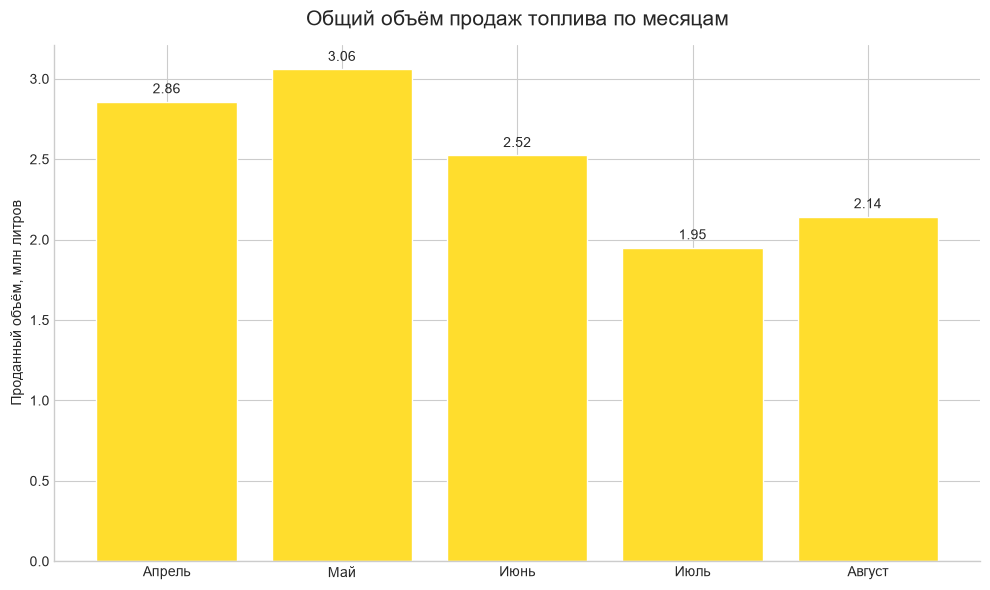

Сохранено: data\processed\fuel_sales_volume_by_month.png


In [27]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(monthly_sales["month_name"], monthly_sales["sold_volume_liters"], color="#FFDD2D")
ax.set_title("Общий объём продаж топлива по месяцам", fontsize=15, pad=14)
ax.set_xlabel("")
ax.set_ylabel("Проданный объём, млн литров")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:.1f}"))
ax.bar_label(bars, labels=[f"{value / 1_000_000:.2f}" for value in monthly_sales["sold_volume_liters"]], padding=4)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
volume_chart = OUTPUT_DIR / "fuel_sales_volume_by_month.png"
fig.savefig(volume_chart, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Сохранено:", volume_chart)

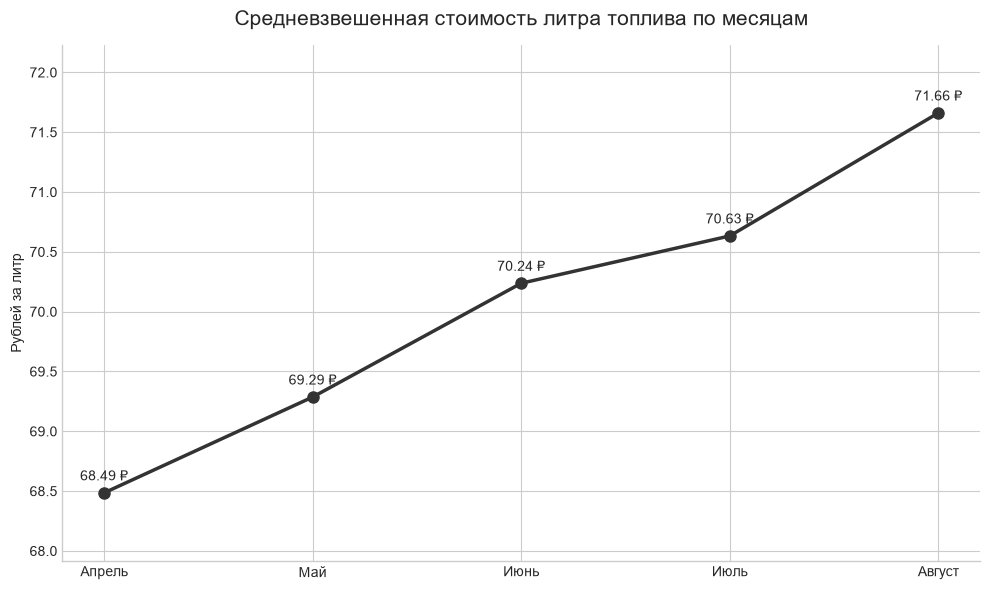

Сохранено: data\processed\fuel_price_per_liter_by_month.png


In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(monthly_sales["month_name"], monthly_sales["weighted_price_rub_per_liter"],
        marker="o", markersize=8, linewidth=2.5, color="#333333")
for x, value in zip(monthly_sales["month_name"], monthly_sales["weighted_price_rub_per_liter"]):
    ax.annotate(f"{value:.2f} ₽", (x, value), xytext=(0, 9), textcoords="offset points", ha="center")
ax.set_title("Средневзвешенная стоимость литра топлива по месяцам", fontsize=15, pad=14)
ax.set_xlabel("")
ax.set_ylabel("Рублей за литр")
ax.spines[["top", "right"]].set_visible(False)
ax.margins(y=0.18)
fig.tight_layout()
price_chart = OUTPUT_DIR / "fuel_price_per_liter_by_month.png"
fig.savefig(price_chart, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Сохранено:", price_chart)

## Динамика продаж по регионам

Каждый регион показан на отдельной панели. Период — полные месяцы с апреля по август 2026 года; цена средневзвешенная по проданному объёму.

In [29]:
region_monthly_charts = fuel_sales_region_monthly[
    fuel_sales_region_monthly["sale_month"].between("2026-04", "2026-08")
].copy()
region_monthly_charts["month_name"] = region_monthly_charts["sale_month"].map(month_labels)
region_monthly_charts.to_csv(OUTPUT_DIR / "fuel_sales_by_region_chart_data.csv", index=False)
regions = fuel_sales_region_total.sort_values("sold_volume_liters", ascending=False)["region_name"].tolist()
assert len(regions) == 16
region_monthly_charts.head()

,sale_month,region_code,region_name,sale_count,active_clients,sold_volume_liters,sales_revenue_rub,weighted_price_rub_per_liter,average_sale_liters,average_sale_rub,month_name
16,2026-04,02,Республика Башкортостан,1028,225,37145.18,2.302519e+06,61.987025,36.133444,2239.804672,Апрель
17,2026-04,16,Республика Татарстан,6267,1480,223109.87,1.435955e+07,64.360886,35.600745,2291.295502,Апрель
18,2026-04,23,Краснодарский край,2355,553,92248.91,6.398417e+06,69.360359,39.171512,2716.950099,Апрель
19,2026-04,24,Красноярский край,1987,507,72772.62,4.968674e+06,68.276698,36.624368,2500.590936,Апрель
20,2026-04,42,Кемеровская область,2036,504,74427.80,4.932383e+06,66.270706,36.555894,2422.584881,Апрель


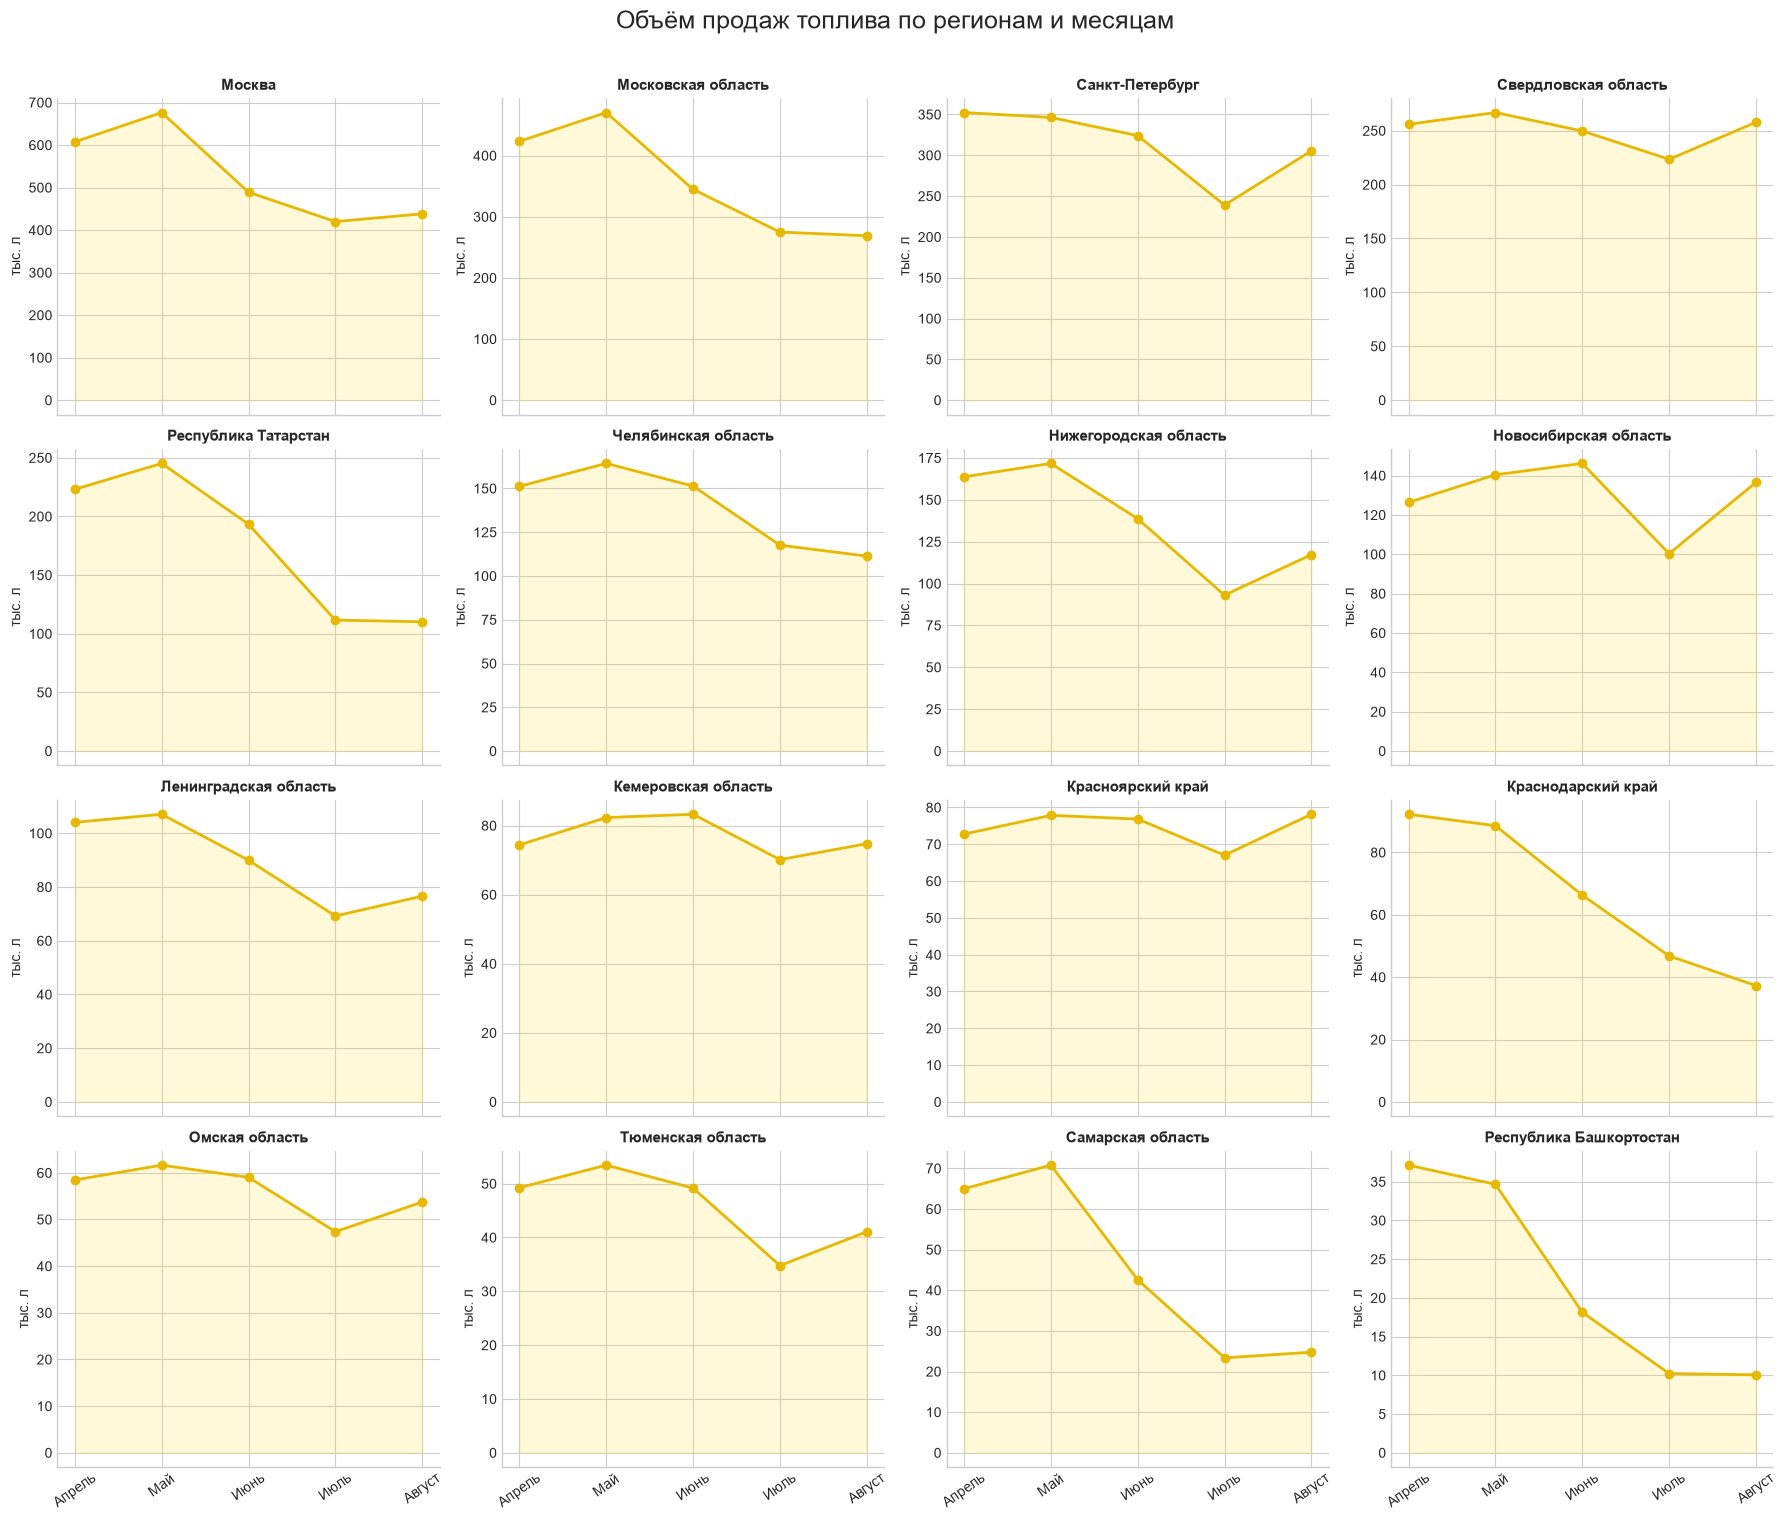

Сохранено: data\processed\fuel_sales_volume_by_month_and_region.png


In [30]:
fig, axes = plt.subplots(4, 4, figsize=(18, 15), sharex=True)
for ax, region in zip(axes.flat, regions):
    part = region_monthly_charts[region_monthly_charts["region_name"].eq(region)]
    ax.plot(part["month_name"], part["sold_volume_liters"] / 1000,
            marker="o", linewidth=2, color="#E6B800")
    ax.fill_between(part["month_name"], part["sold_volume_liters"] / 1000,
                    alpha=0.18, color="#FFDD2D")
    ax.set_title(region, fontsize=11, fontweight="bold")
    ax.set_ylabel("тыс. л")
    ax.tick_params(axis="x", rotation=35)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Объём продаж топлива по регионам и месяцам", fontsize=18, y=1.01)
fig.tight_layout()
region_volume_chart = OUTPUT_DIR / "fuel_sales_volume_by_month_and_region.png"
fig.savefig(region_volume_chart, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Сохранено:", region_volume_chart)

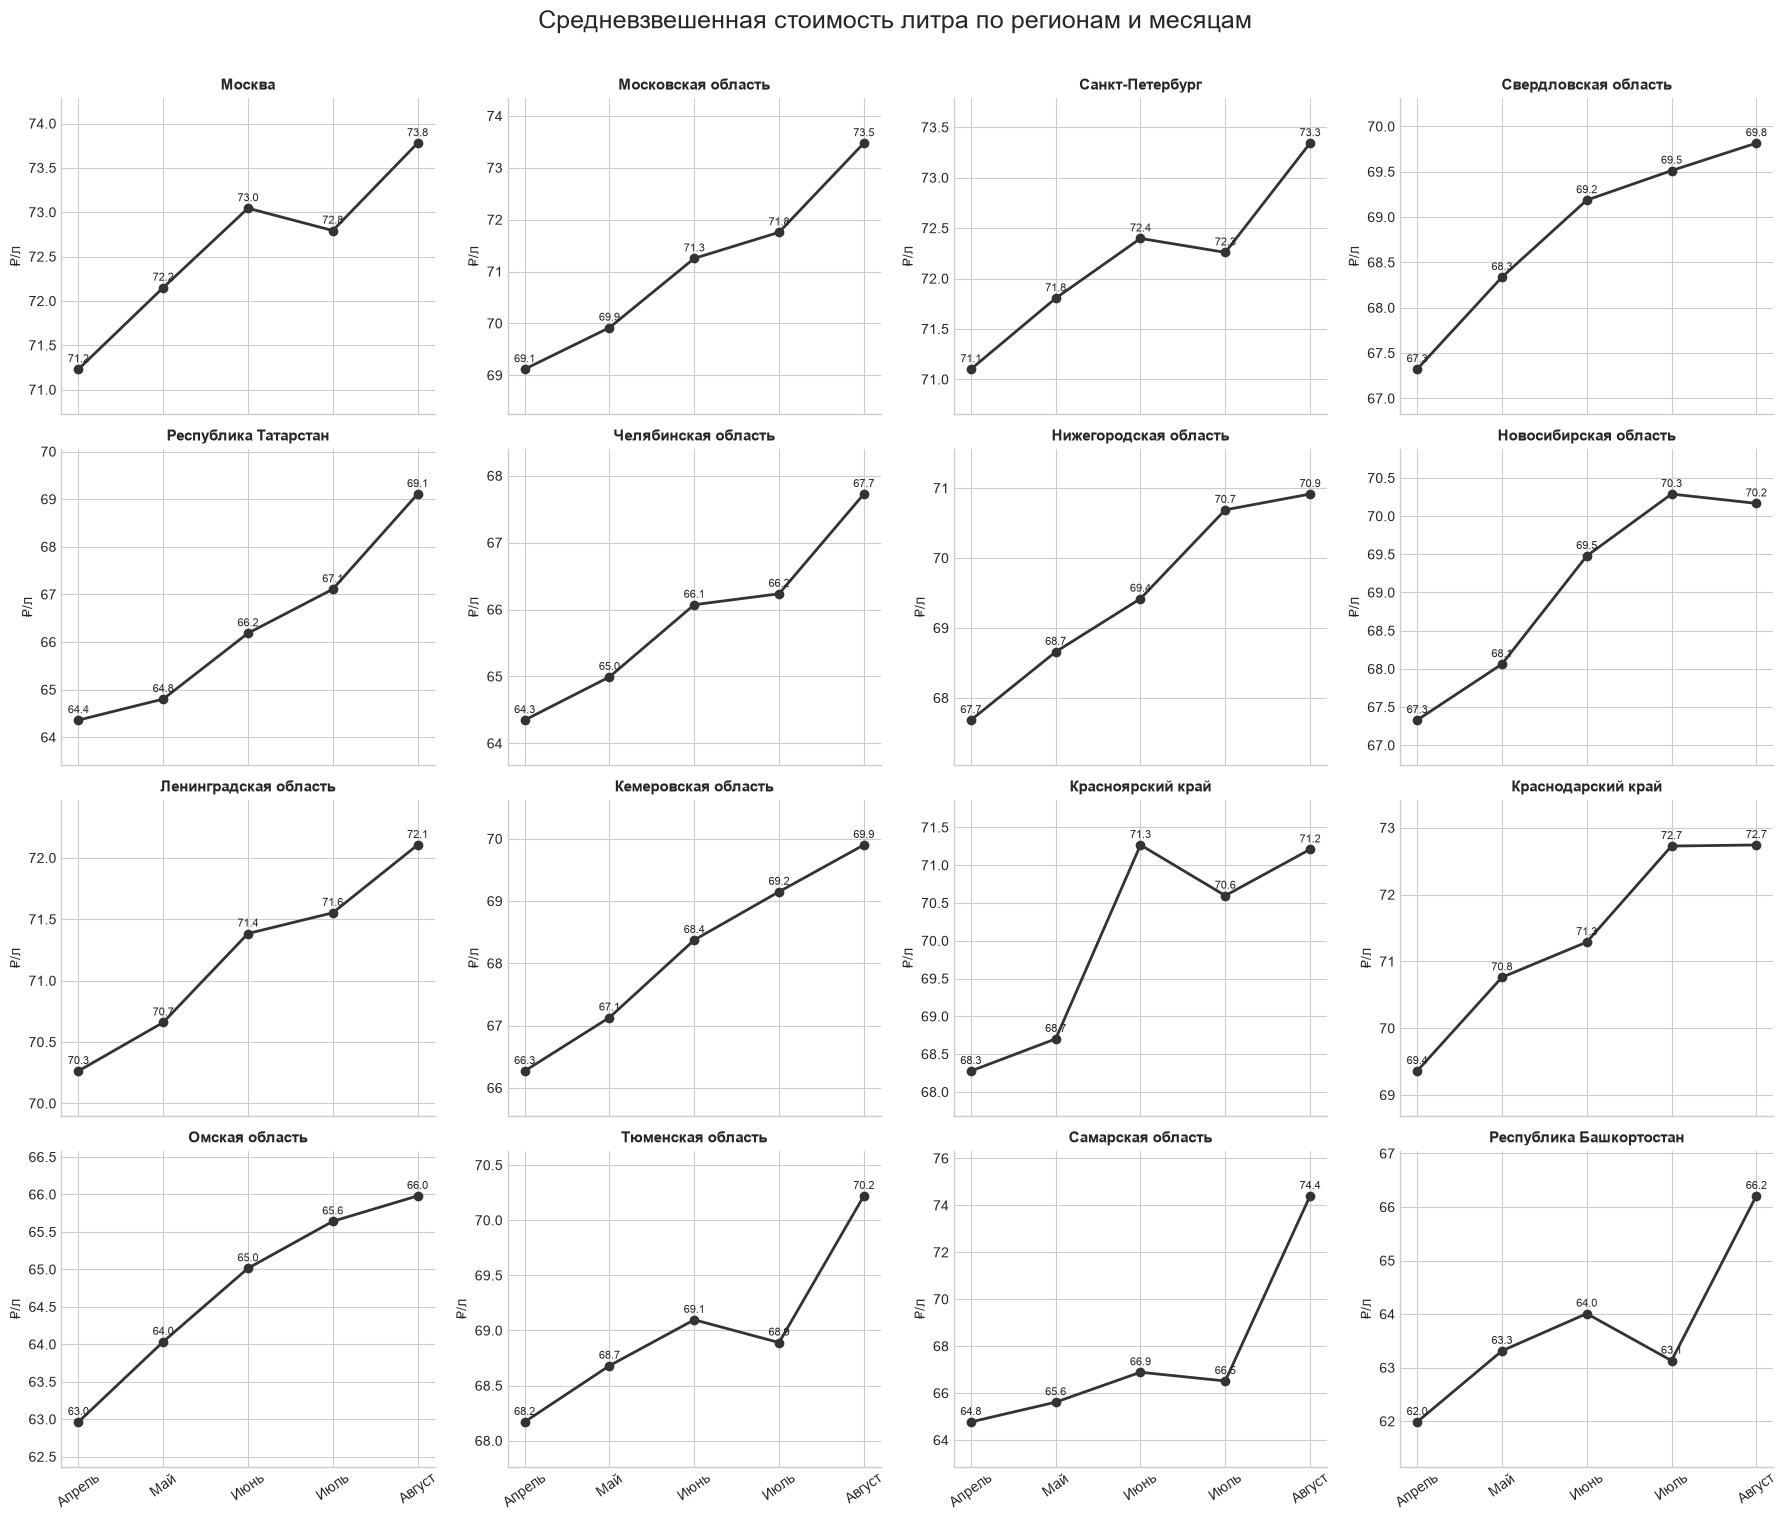

Сохранено: data\processed\fuel_price_per_liter_by_month_and_region.png


In [31]:
fig, axes = plt.subplots(4, 4, figsize=(18, 15), sharex=True)
for ax, region in zip(axes.flat, regions):
    part = region_monthly_charts[region_monthly_charts["region_name"].eq(region)]
    ax.plot(part["month_name"], part["weighted_price_rub_per_liter"],
            marker="o", linewidth=2, color="#333333")
    for x, value in zip(part["month_name"], part["weighted_price_rub_per_liter"]):
        ax.annotate(f"{value:.1f}", (x, value), xytext=(0, 5),
                    textcoords="offset points", ha="center", fontsize=8)
    ax.set_title(region, fontsize=11, fontweight="bold")
    ax.set_ylabel("₽/л")
    ax.tick_params(axis="x", rotation=35)
    ax.margins(y=0.2)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Средневзвешенная стоимость литра по регионам и месяцам", fontsize=18, y=1.01)
fig.tight_layout()
region_price_chart = OUTPUT_DIR / "fuel_price_per_liter_by_month_and_region.png"
fig.savefig(region_price_chart, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Сохранено:", region_price_chart)

## Нарушения ПДД по регионам

Регион берётся из `region_name` таблицы штрафов — это место фиксации нарушения. Для сопоставимости с топливными графиками показаны те же 16 регионов и полные месяцы с апреля по август 2026 года.

In [32]:
fines = pd.read_csv(
    OUTPUT_DIR / "fines_clean.csv",
    dtype={"bill_id": "string", "client_id": "string"},
    parse_dates=["bill_offence_date"], low_memory=False,
)
fines["offence_month"] = fines["bill_offence_date"].dt.to_period("M").astype(str)
fines["fine_amount_rub"] = fines["total_fine_amount"] / 100
fines_chart_source = fines[
    fines["offence_month"].between("2026-04", "2026-08")
    & fines["region_name"].isin(regions)
].copy()
fines_region_monthly = fines_chart_source.groupby(
    ["offence_month", "region_name"], as_index=False
).agg(
    fine_count=("bill_id", "nunique"),
    active_clients=("client_id", "nunique"),
    total_fine_amount_rub=("fine_amount_rub", "sum"),
    average_fine_amount_rub=("fine_amount_rub", "mean"),
)
full_index = pd.MultiIndex.from_product(
    [list(month_labels), regions], names=["offence_month", "region_name"]
)
fines_region_monthly = (fines_region_monthly.set_index(["offence_month", "region_name"])
                        .reindex(full_index, fill_value=0).reset_index())
fines_region_monthly["month_name"] = fines_region_monthly["offence_month"].map(month_labels)
fines_region_monthly.to_csv(OUTPUT_DIR / "fines_by_region_chart_data.csv", index=False)
assert len(fines_region_monthly) == 16 * 5
fines_region_monthly.head()

,offence_month,region_name,fine_count,active_clients,total_fine_amount_rub,average_fine_amount_rub,month_name
0,2026-04,Москва,2526,1379,2727933.32,1079.941932,Апрель
1,2026-04,Московская область,2207,1267,1832166.66,830.161604,Апрель
2,2026-04,Санкт-Петербург,1373,740,1213400.00,883.758194,Апрель
3,2026-04,Свердловская область,782,494,765849.96,979.347775,Апрель
4,2026-04,Республика Татарстан,881,486,794800.00,902.156640,Апрель


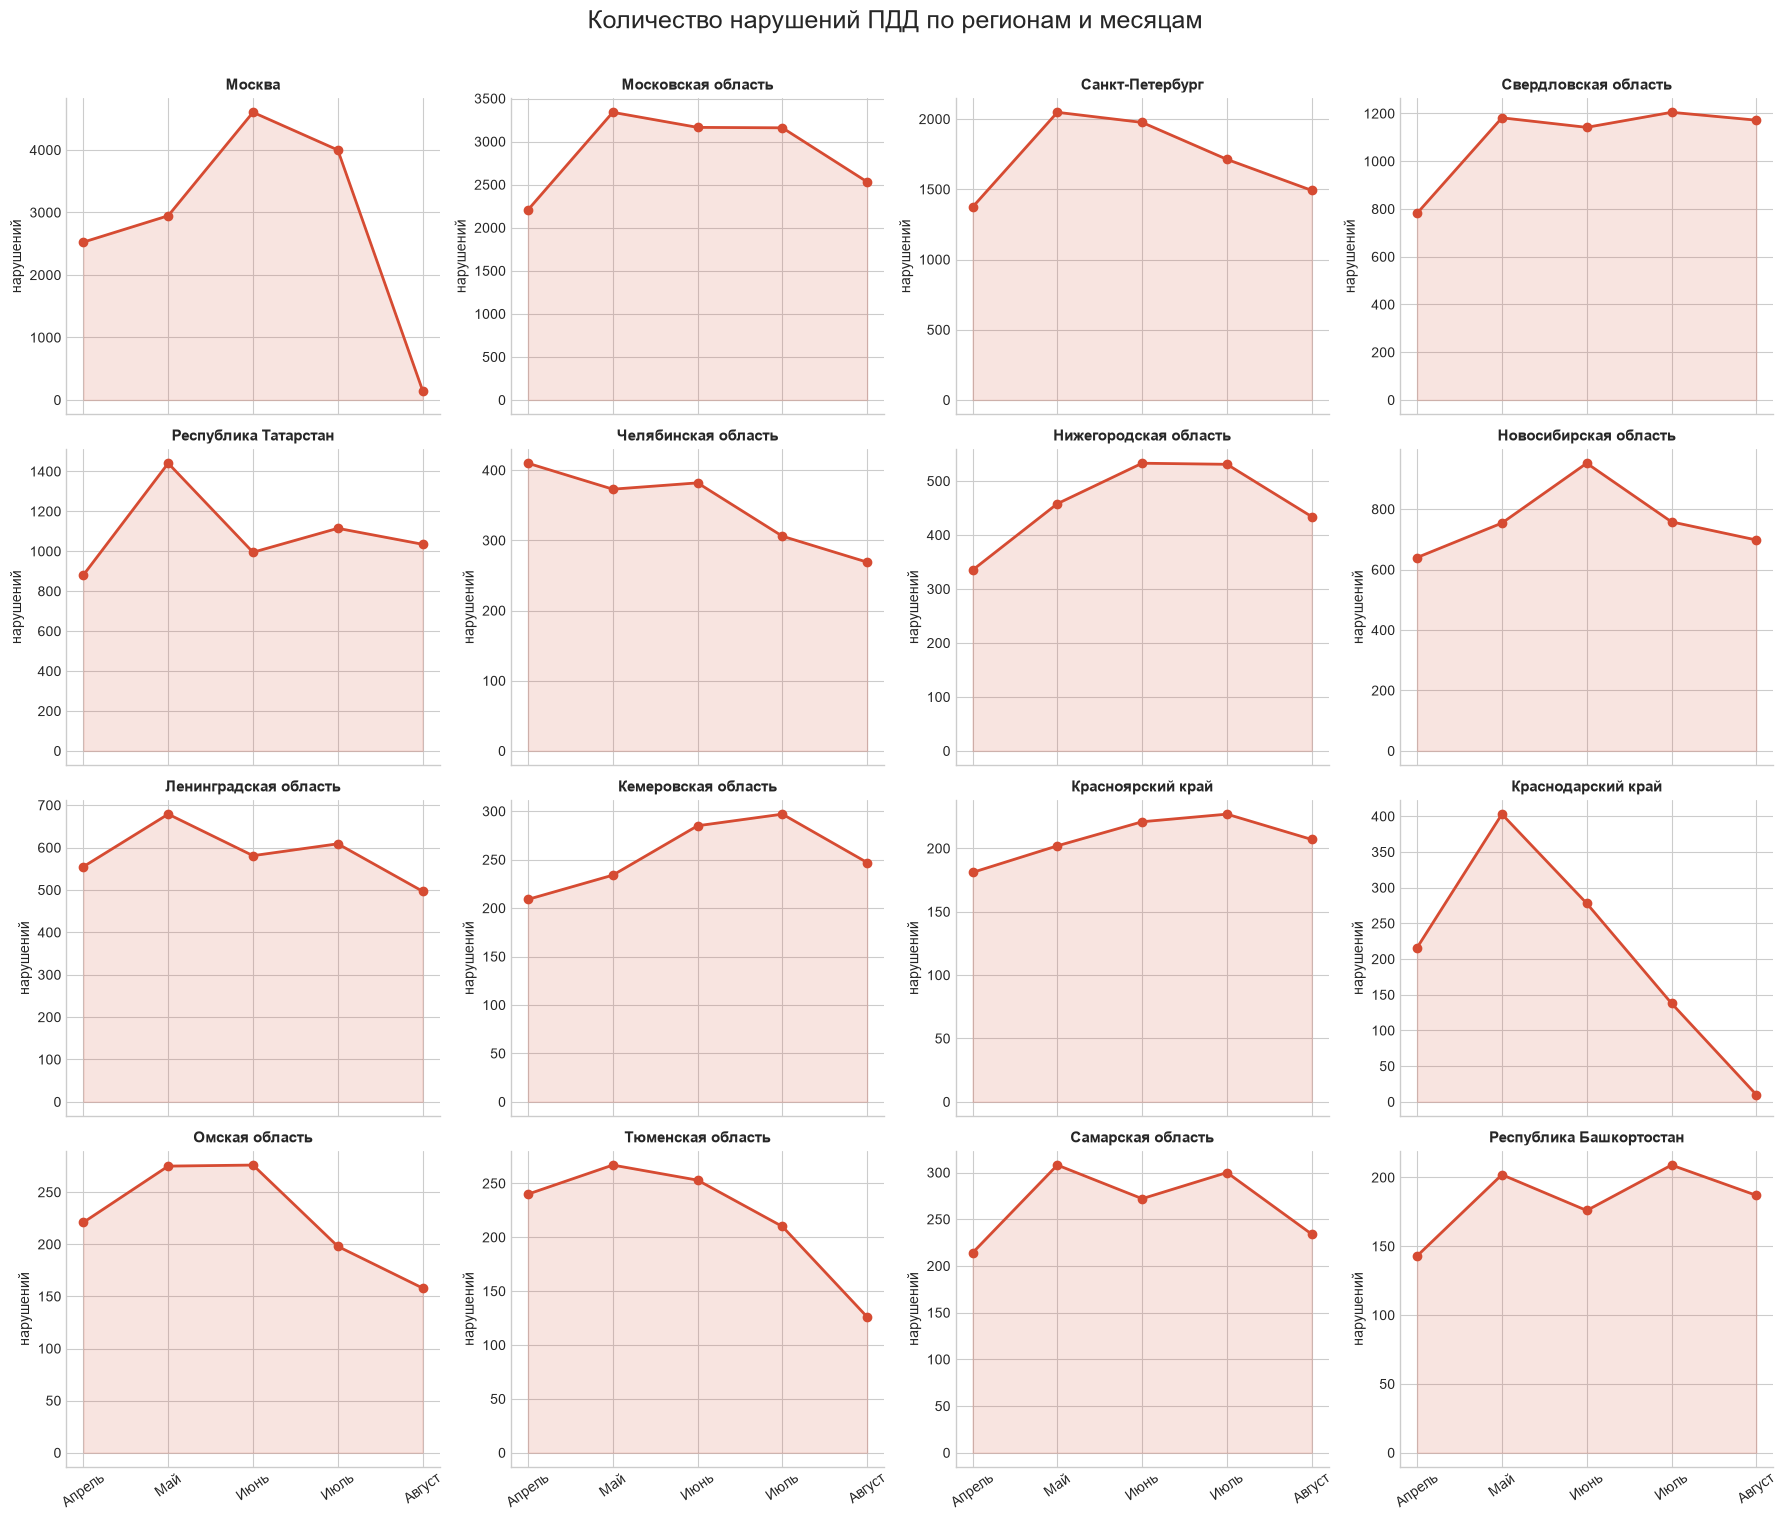

Сохранено: data\processed\fines_count_by_month_and_region.png


In [33]:
fig, axes = plt.subplots(4, 4, figsize=(18, 15), sharex=True)
for ax, region in zip(axes.flat, regions):
    part = fines_region_monthly[fines_region_monthly["region_name"].eq(region)]
    ax.plot(part["month_name"], part["fine_count"],
            marker="o", linewidth=2, color="#D64B32")
    ax.fill_between(part["month_name"], part["fine_count"],
                    alpha=0.15, color="#D64B32")
    ax.set_title(region, fontsize=11, fontweight="bold")
    ax.set_ylabel("нарушений")
    ax.tick_params(axis="x", rotation=35)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Количество нарушений ПДД по регионам и месяцам", fontsize=18, y=1.01)
fig.tight_layout()
fines_count_chart = OUTPUT_DIR / "fines_count_by_month_and_region.png"
fig.savefig(fines_count_chart, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Сохранено:", fines_count_chart)

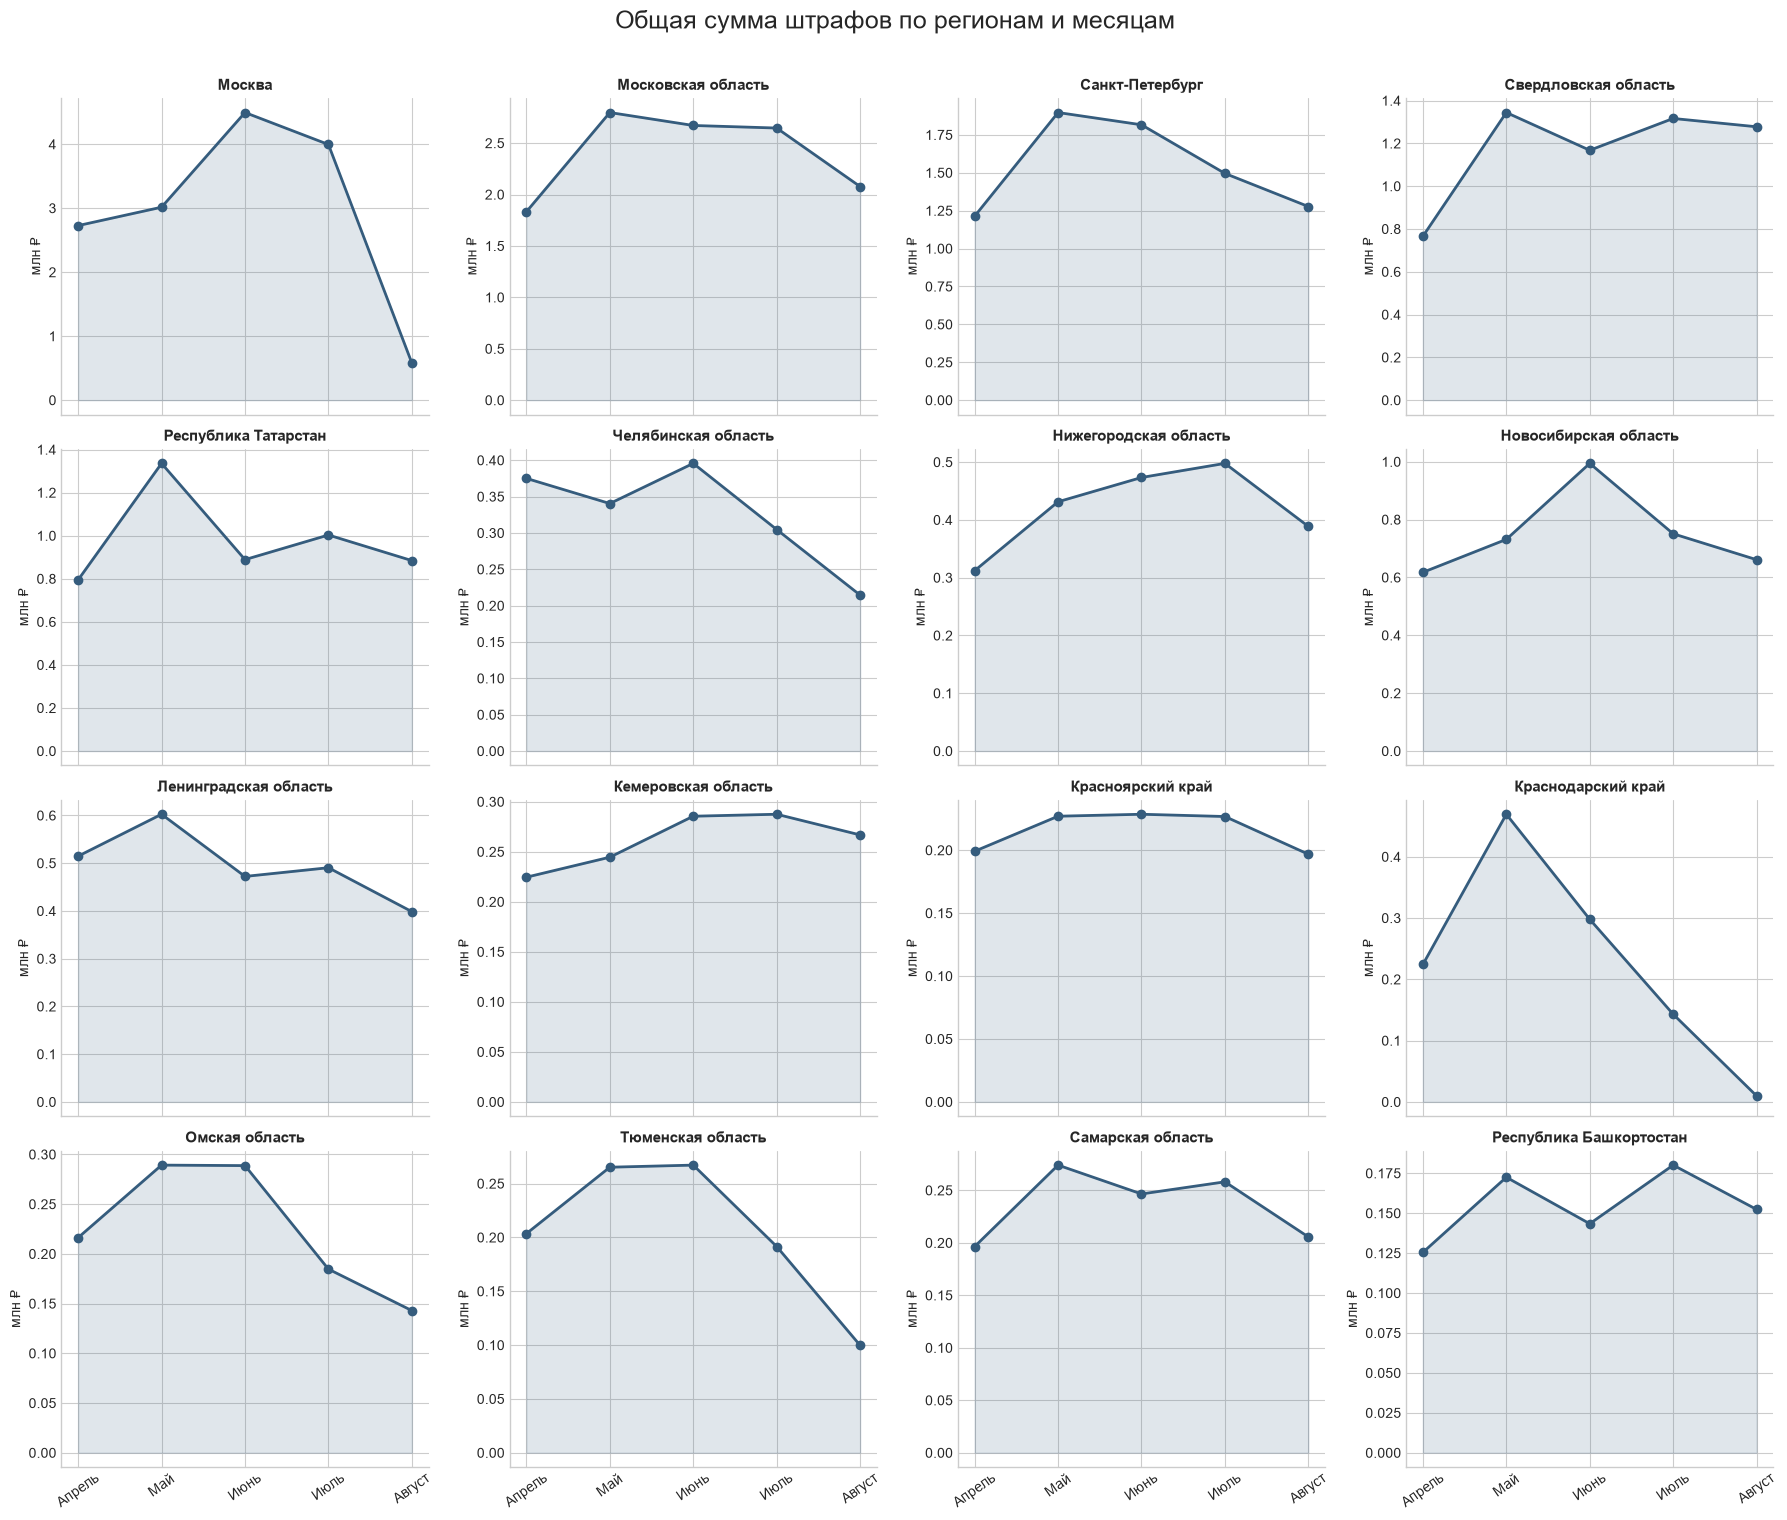

Сохранено: data\processed\fines_amount_by_month_and_region.png


In [34]:
fig, axes = plt.subplots(4, 4, figsize=(18, 15), sharex=True)
for ax, region in zip(axes.flat, regions):
    part = fines_region_monthly[fines_region_monthly["region_name"].eq(region)]
    ax.plot(part["month_name"], part["total_fine_amount_rub"] / 1_000_000,
            marker="o", linewidth=2, color="#355C7D")
    ax.fill_between(part["month_name"], part["total_fine_amount_rub"] / 1_000_000,
                    alpha=0.15, color="#355C7D")
    ax.set_title(region, fontsize=11, fontweight="bold")
    ax.set_ylabel("млн ₽")
    ax.tick_params(axis="x", rotation=35)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Общая сумма штрафов по регионам и месяцам", fontsize=18, y=1.01)
fig.tight_layout()
fines_amount_chart = OUTPUT_DIR / "fines_amount_by_month_and_region.png"
fig.savefig(fines_amount_chart, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Сохранено:", fines_amount_chart)

## Корреляции топлива и нарушений ПДД

Сначала рассчитывается общая матрица по пяти месячным итогам, затем — отдельные корреляции для каждого из 16 регионов. Используется коэффициент Пирсона. Это разведывательный анализ: пять наблюдений на коэффициент недостаточно для причинных выводов и надёжной проверки значимости.

In [35]:
overall_fines_monthly = fines[
    fines["offence_month"].between("2026-04", "2026-08")
].groupby("offence_month", as_index=False).agg(
    fine_count=("bill_id", "nunique"),
    fined_clients=("client_id", "nunique"),
    total_fine_amount_rub=("fine_amount_rub", "sum"),
    average_fine_amount_rub=("fine_amount_rub", "mean"),
)
correlation_general_data = monthly_sales.rename(
    columns={"sale_month": "month", "sale_count": "fuel_sale_count"}
).merge(overall_fines_monthly.rename(columns={"offence_month": "month"}),
        on="month", how="inner", validate="one_to_one")
correlation_variables = [
    "weighted_price_rub_per_liter", "sold_volume_liters",
    "fuel_sale_count", "sales_revenue_rub",
    "fine_count", "fined_clients",
    "total_fine_amount_rub", "average_fine_amount_rub",
]
correlation_general = correlation_general_data[correlation_variables].corr(method="pearson")
correlation_general.index.name = "variable"
correlation_general_data.to_csv(OUTPUT_DIR / "correlation_general_monthly_data.csv", index=False)
correlation_general.to_csv(OUTPUT_DIR / "correlation_general.csv")
correlation_general.round(3)

,weighted_price_rub_per_liter,sold_volume_liters,fuel_sale_count,sales_revenue_rub,fine_count,fined_clients,total_fine_amount_rub,average_fine_amount_rub
variable,,,,,,,,
weighted_price_rub_per_liter,1.000,-0.822,-0.860,-0.787,-0.137,-0.147,-0.172,-0.831
sold_volume_liters,-0.822,1.000,0.969,0.998,0.091,0.100,0.138,0.935
fuel_sale_count,-0.860,0.969,1.000,0.961,0.227,0.243,0.273,0.988
sales_revenue_rub,-0.787,0.998,0.961,1.000,0.092,0.099,0.138,0.928
fine_count,-0.137,0.091,0.227,0.092,1.000,0.999,0.999,0.370
fined_clients,-0.147,0.100,0.243,0.099,0.999,1.000,0.999,0.385
total_fine_amount_rub,-0.172,0.138,0.273,0.138,0.999,0.999,1.000,0.414
average_fine_amount_rub,-0.831,0.935,0.988,0.928,0.370,0.385,0.414,1.000


In [36]:
correlation_region_data = region_monthly_charts.rename(columns={
    "sale_month": "month", "sale_count": "fuel_sale_count",
}).merge(
    fines_region_monthly.rename(columns={
        "offence_month": "month", "active_clients": "fined_clients",
    })[["month", "region_name", "fine_count", "fined_clients",
        "total_fine_amount_rub", "average_fine_amount_rub"]],
    on=["month", "region_name"], how="inner", validate="one_to_one",
)
assert len(correlation_region_data) == 16 * 5

summary_pairs = {
    "corr_price_fine_count": ("weighted_price_rub_per_liter", "fine_count"),
    "corr_volume_fine_count": ("sold_volume_liters", "fine_count"),
    "corr_sales_count_fine_count": ("fuel_sale_count", "fine_count"),
    "corr_fuel_revenue_fine_count": ("sales_revenue_rub", "fine_count"),
    "corr_price_total_fine_amount": ("weighted_price_rub_per_liter", "total_fine_amount_rub"),
    "corr_volume_total_fine_amount": ("sold_volume_liters", "total_fine_amount_rub"),
}
regional_summary = []
regional_full = []
for region, part in correlation_region_data.groupby("region_name", sort=False):
    matrix = part[correlation_variables].corr(method="pearson")
    row = {"region_name": region, "observations": len(part)}
    row.update({name: matrix.loc[x, y] for name, (x, y) in summary_pairs.items()})
    regional_summary.append(row)
    long_matrix = matrix.rename_axis("variable_x").reset_index().melt(
        id_vars="variable_x", var_name="variable_y", value_name="correlation"
    )
    long_matrix.insert(0, "region_name", region)
    long_matrix["observations"] = len(part)
    regional_full.append(long_matrix)

correlation_by_region = pd.DataFrame(regional_summary).sort_values("region_name")
correlation_by_region_full = pd.concat(regional_full, ignore_index=True)
correlation_region_data.to_csv(OUTPUT_DIR / "correlation_by_region_monthly_data.csv", index=False)
correlation_by_region.to_csv(OUTPUT_DIR / "correlation_by_region.csv", index=False)
correlation_by_region_full.to_csv(OUTPUT_DIR / "correlation_by_region_full.csv", index=False)
correlation_by_region.round(3)

,region_name,observations,corr_price_fine_count,corr_volume_fine_count,corr_sales_count_fine_count,corr_fuel_revenue_fine_count,corr_price_total_fine_amount,corr_volume_total_fine_amount
4,Кемеровская область,5,0.666,-0.092,0.788,0.105,0.798,-0.056
2,Краснодарский край,5,-0.602,0.808,0.833,0.824,-0.571,0.790
3,Красноярский край,5,0.791,-0.260,0.442,-0.010,0.151,-0.180
5,Ленинградская область,5,-0.481,0.418,0.580,0.412,-0.785,0.716
14,Москва,5,-0.269,0.050,0.131,0.040,-0.280,0.047
6,Московская область,5,0.058,0.068,0.176,0.088,0.033,0.081
7,Нижегородская область,5,0.607,-0.554,-0.527,-0.538,0.575,-0.542
8,Новосибирская область,5,0.361,0.369,0.385,0.427,0.329,0.344
9,Омская область,5,-0.485,0.710,0.932,0.695,-0.474,0.737
0,Республика Башкортостан,5,0.333,-0.508,-0.488,-0.499,0.140,-0.385


## Тепловые карты корреляций

Красный цвет означает положительную связь, синий — отрицательную. Чем насыщеннее цвет, тем ближе модуль коэффициента к единице.

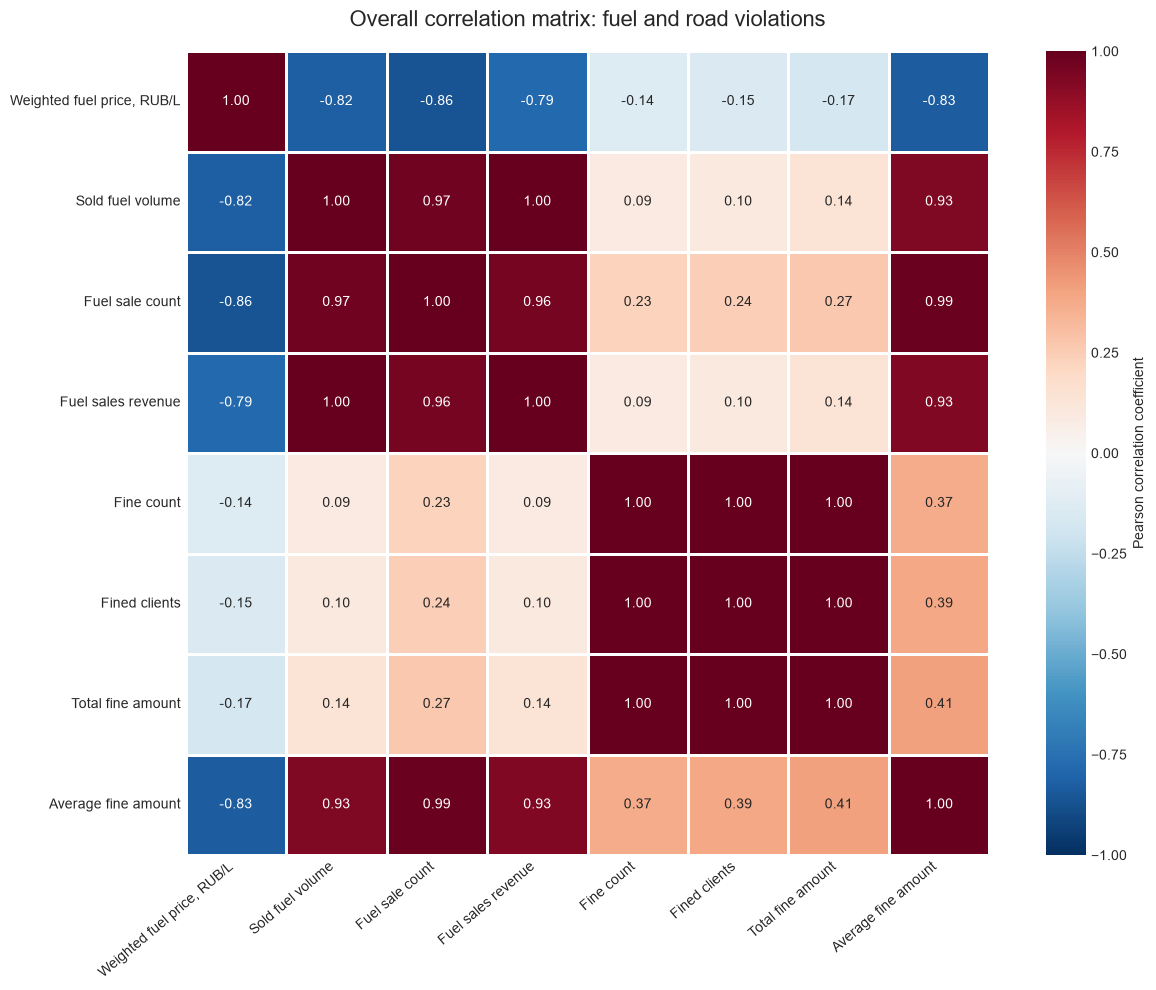

Сохранено: data\processed\correlation_general_heatmap.png


In [37]:
import seaborn as sns

correlation_labels = {
    "weighted_price_rub_per_liter": "Weighted fuel price, RUB/L",
    "sold_volume_liters": "Sold fuel volume",
    "fuel_sale_count": "Fuel sale count",
    "sales_revenue_rub": "Fuel sales revenue",
    "fine_count": "Fine count",
    "fined_clients": "Fined clients",
    "total_fine_amount_rub": "Total fine amount",
    "average_fine_amount_rub": "Average fine amount",
}
general_heatmap = correlation_general.rename(
    index=correlation_labels, columns=correlation_labels
)
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(general_heatmap, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.8,
            cbar_kws={"label": "Pearson correlation coefficient"}, ax=ax)
ax.set_title("Overall correlation matrix: fuel and road violations", fontsize=16, pad=18)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
fig.tight_layout()
general_correlation_chart = OUTPUT_DIR / "correlation_general_heatmap.png"
fig.savefig(general_correlation_chart, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Сохранено:", general_correlation_chart)

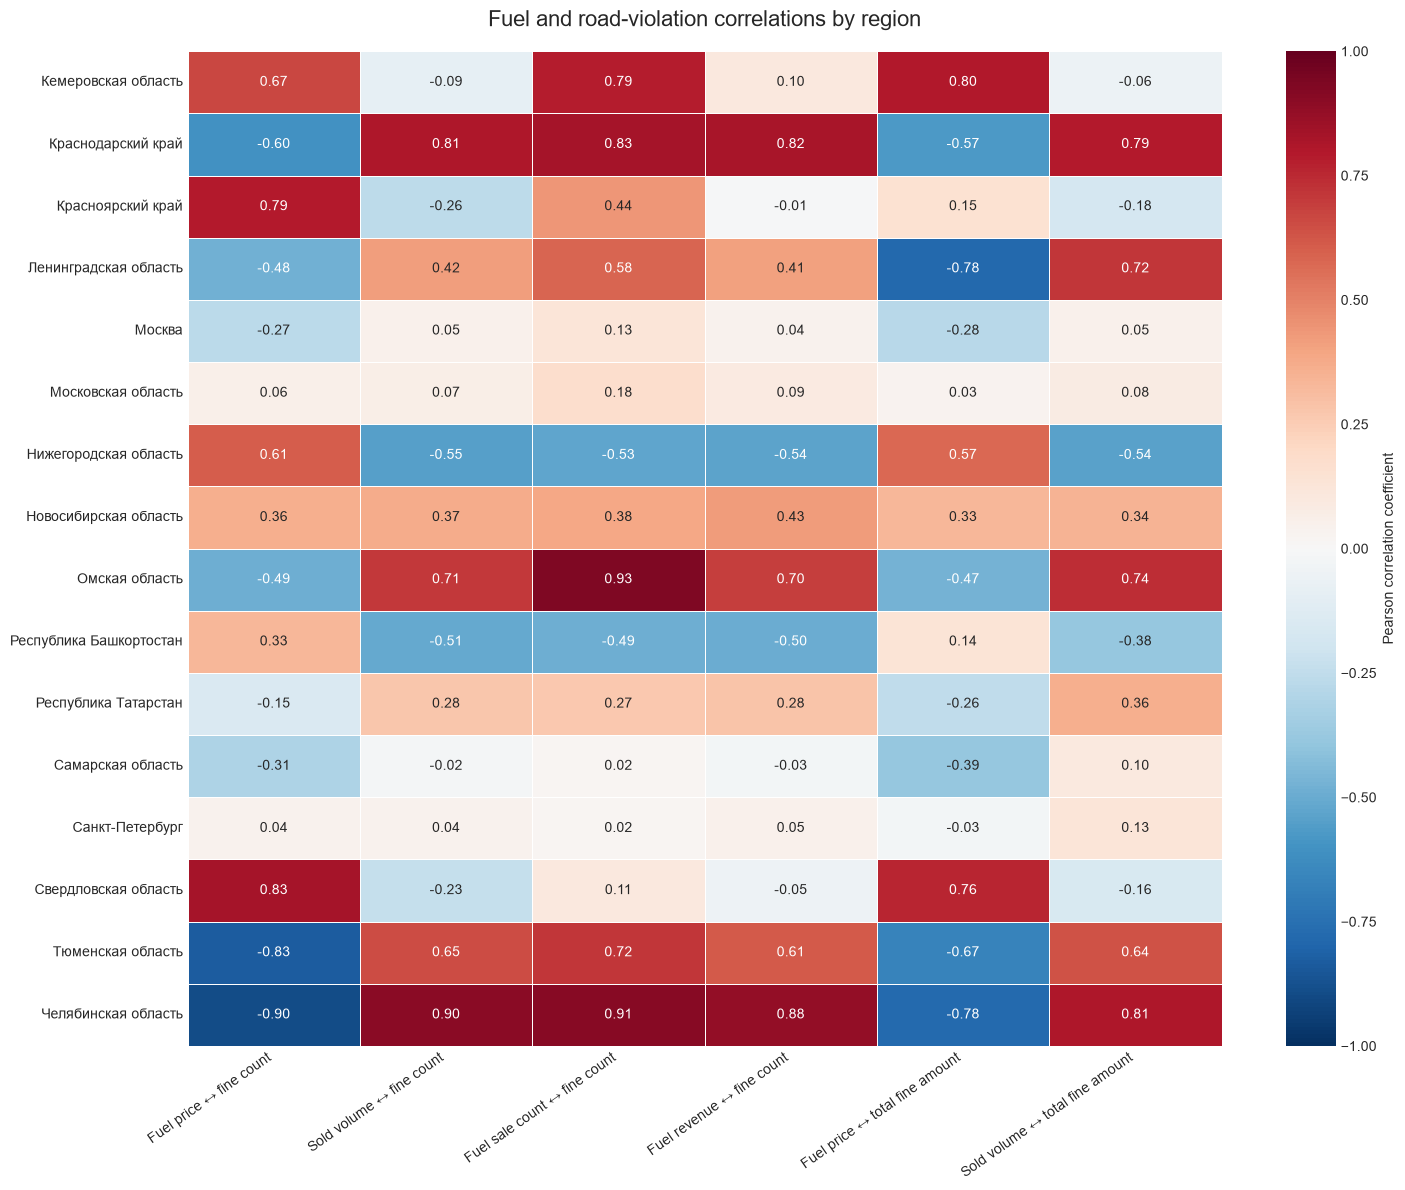

Сохранено: data\processed\correlation_by_region_heatmap.png


In [38]:
regional_labels = {
    "corr_price_fine_count": "Fuel price ↔ fine count",
    "corr_volume_fine_count": "Sold volume ↔ fine count",
    "corr_sales_count_fine_count": "Fuel sale count ↔ fine count",
    "corr_fuel_revenue_fine_count": "Fuel revenue ↔ fine count",
    "corr_price_total_fine_amount": "Fuel price ↔ total fine amount",
    "corr_volume_total_fine_amount": "Sold volume ↔ total fine amount",
}
regional_heatmap = (correlation_by_region.set_index("region_name")
                    [list(regional_labels)].rename(columns=regional_labels))
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(regional_heatmap, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, linewidths=0.7,
            cbar_kws={"label": "Pearson correlation coefficient"}, ax=ax)
ax.set_title("Fuel and road-violation correlations by region", fontsize=16, pad=18)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
fig.tight_layout()
regional_correlation_chart = OUTPUT_DIR / "correlation_by_region_heatmap.png"
fig.savefig(regional_correlation_chart, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Сохранено:", regional_correlation_chart)

## Key regional correlations

This ranked chart compares the two most interpretable regional relationships with fine count. Values are Pearson coefficients calculated from five monthly observations.

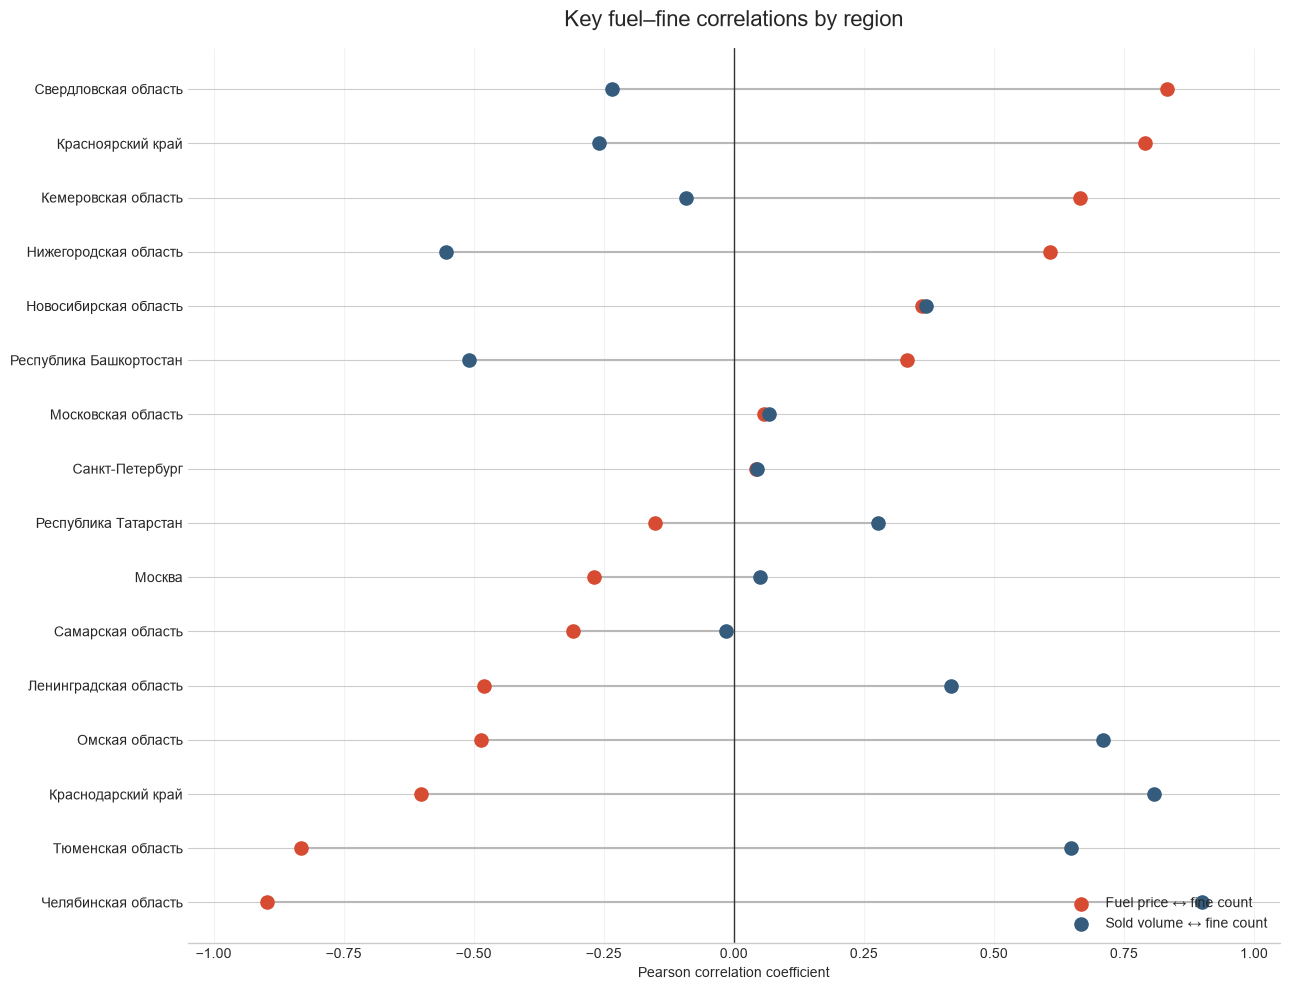

Saved: data\processed\correlation_by_region_ranked.png


In [39]:
ranked_correlations = correlation_by_region.sort_values(
    "corr_price_fine_count", ascending=True
).reset_index(drop=True)
y_positions = range(len(ranked_correlations))
fig, ax = plt.subplots(figsize=(13, 10))
ax.hlines(y_positions,
          ranked_correlations["corr_price_fine_count"],
          ranked_correlations["corr_volume_fine_count"],
          color="#B8B8B8", linewidth=1.5, zorder=1)
ax.scatter(ranked_correlations["corr_price_fine_count"], y_positions,
           s=90, color="#D64B32", label="Fuel price ↔ fine count", zorder=2)
ax.scatter(ranked_correlations["corr_volume_fine_count"], y_positions,
           s=90, color="#355C7D", label="Sold volume ↔ fine count", zorder=2)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_yticks(list(y_positions), ranked_correlations["region_name"])
ax.set_xlim(-1.05, 1.05)
ax.set_xlabel("Pearson correlation coefficient")
ax.set_ylabel("")
ax.set_title("Key fuel–fine correlations by region", fontsize=16, pad=16)
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right", "left"]].set_visible(False)
fig.tight_layout()
ranked_correlation_chart = OUTPUT_DIR / "correlation_by_region_ranked.png"
fig.savefig(ranked_correlation_chart, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved:", ranked_correlation_chart)

## Violations per fined client by region

The denominator is the number of unique clients with at least one recorded violation in the corresponding region and period. Therefore, this metric describes violations per fined client, not violations per resident or per all drivers.

In [40]:
violations_per_client_monthly = fines_region_monthly.copy()
violations_per_client_monthly["violations_per_fined_client"] = (
    violations_per_client_monthly["fine_count"]
    / violations_per_client_monthly["active_clients"].replace(0, pd.NA)
)
violations_per_client_total = fines_chart_source.groupby("region_name", as_index=False).agg(
    fine_count=("bill_id", "nunique"),
    fined_clients=("client_id", "nunique"),
)
violations_per_client_total["violations_per_fined_client"] = (
    violations_per_client_total["fine_count"] / violations_per_client_total["fined_clients"]
)
violations_per_client_monthly.to_csv(
    OUTPUT_DIR / "violations_per_fined_client_by_region_monthly.csv", index=False
)
violations_per_client_total.to_csv(
    OUTPUT_DIR / "violations_per_fined_client_by_region_total.csv", index=False
)
violations_per_client_total.sort_values("violations_per_fined_client", ascending=False)

,region_name,fine_count,fined_clients,violations_per_fined_client
10,Республика Татарстан,5467,1335,4.095131
7,Новосибирская область,3802,954,3.985325
12,Санкт-Петербург,8602,2162,3.978723
4,Москва,14228,3614,3.936912
14,Тюменская область,1096,289,3.792388
8,Омская область,1128,314,3.592357
5,Московская область,14404,4123,3.493573
13,Свердловская область,5483,1606,3.414072
11,Самарская область,1328,396,3.353535
1,Краснодарский край,1045,337,3.100890


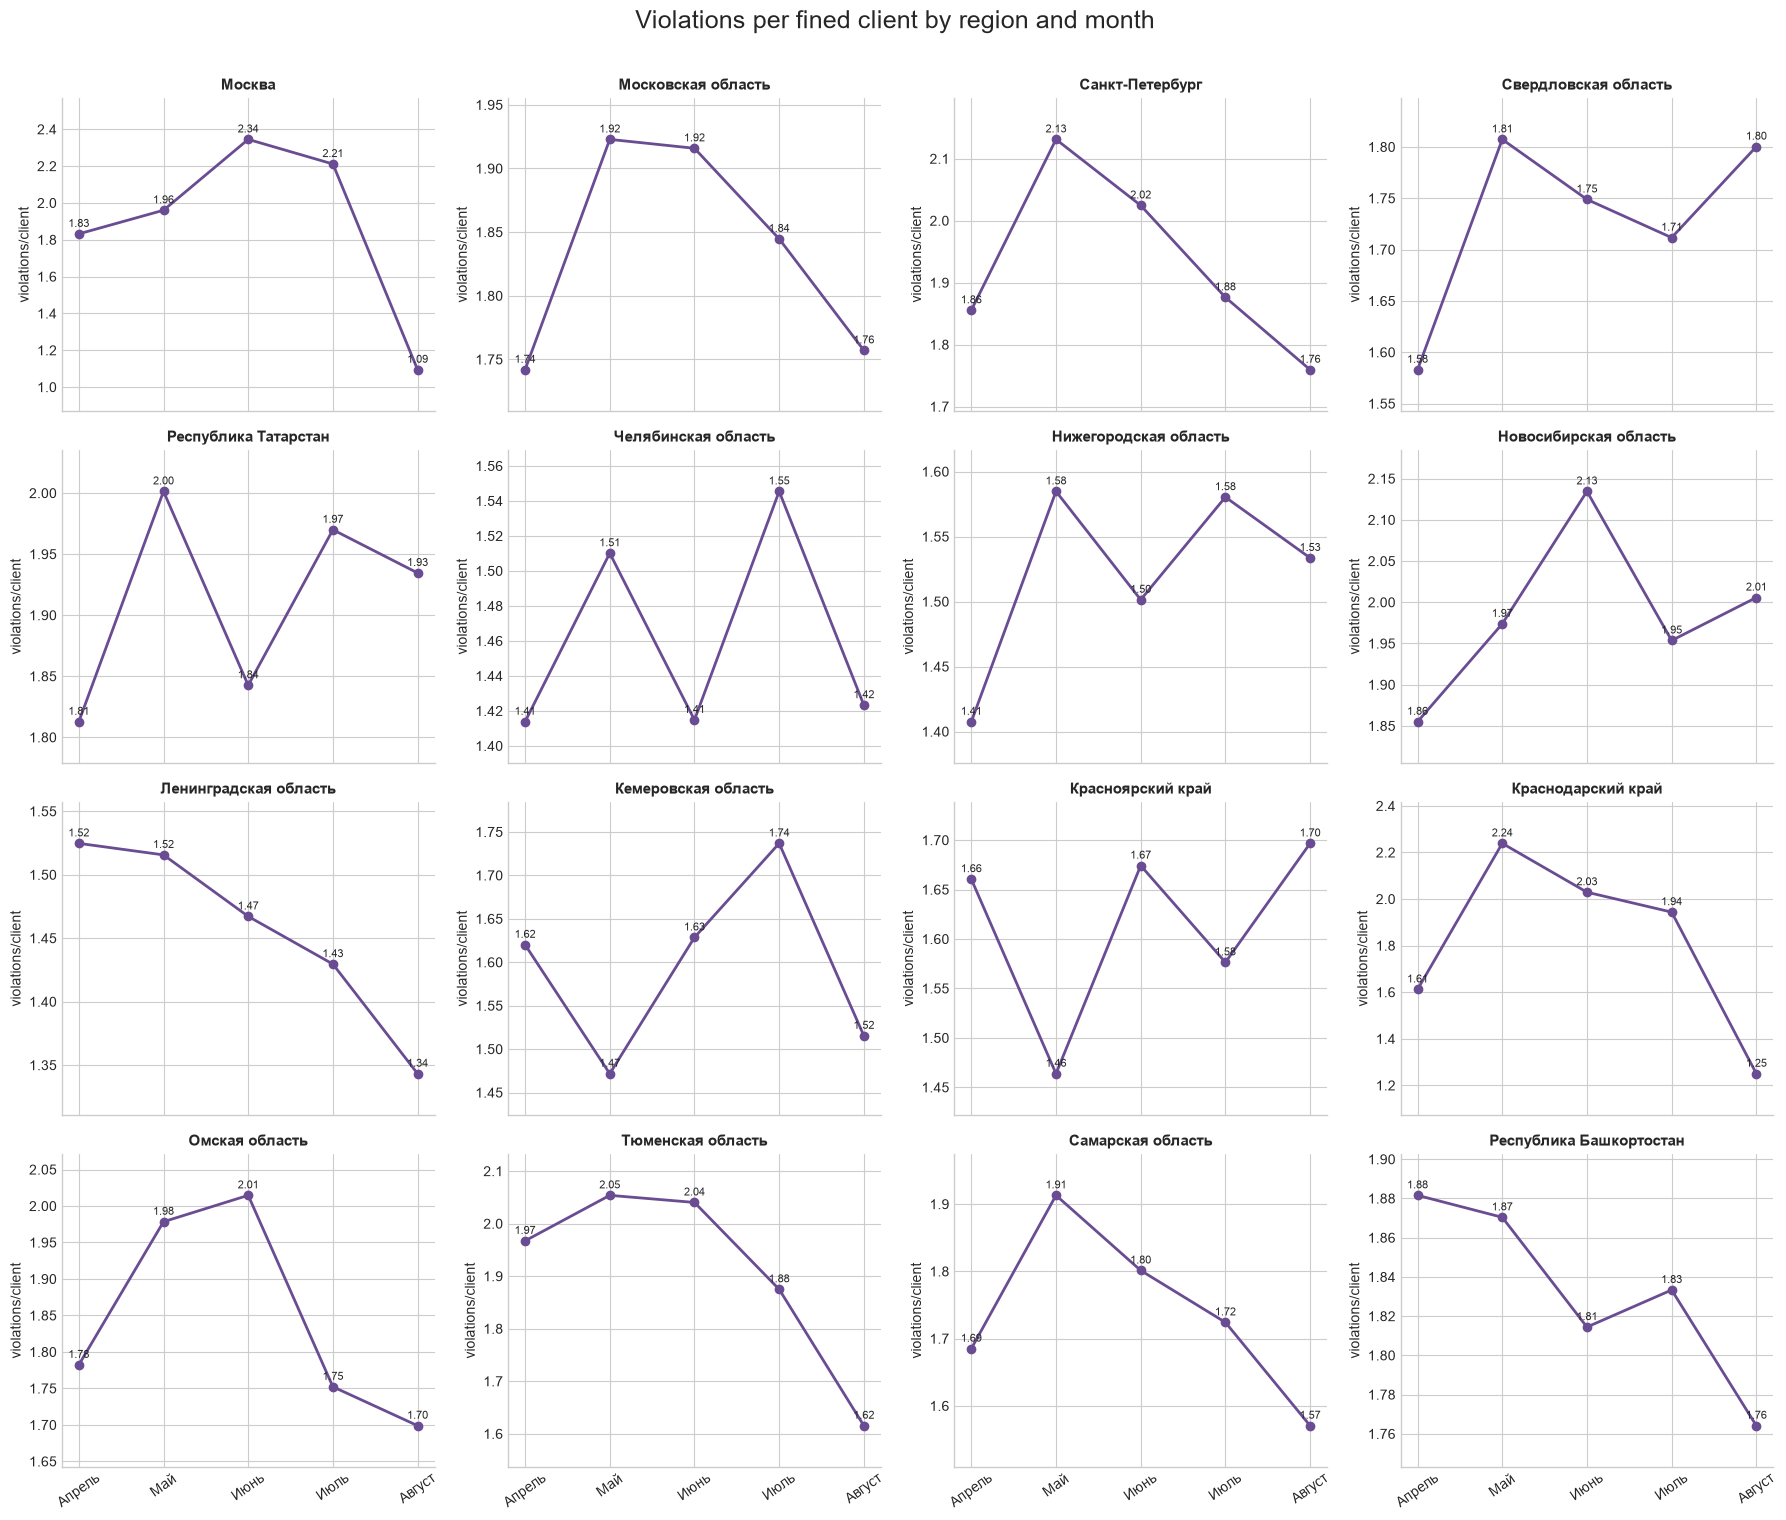

Saved: data\processed\violations_per_fined_client_by_month_and_region.png


In [41]:
fig, axes = plt.subplots(4, 4, figsize=(18, 15), sharex=True)
for ax, region in zip(axes.flat, regions):
    part = violations_per_client_monthly[
        violations_per_client_monthly["region_name"].eq(region)
    ]
    ax.plot(part["month_name"], part["violations_per_fined_client"],
            marker="o", linewidth=2, color="#6A4C93")
    for x, value in zip(part["month_name"], part["violations_per_fined_client"]):
        ax.annotate(f"{value:.2f}", (x, value), xytext=(0, 5),
                    textcoords="offset points", ha="center", fontsize=8)
    ax.set_title(region, fontsize=11, fontweight="bold")
    ax.set_ylabel("violations/client")
    ax.tick_params(axis="x", rotation=35)
    ax.margins(y=0.18)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Violations per fined client by region and month", fontsize=18, y=1.01)
fig.tight_layout()
violations_per_client_monthly_chart = OUTPUT_DIR / "violations_per_fined_client_by_month_and_region.png"
fig.savefig(violations_per_client_monthly_chart, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved:", violations_per_client_monthly_chart)

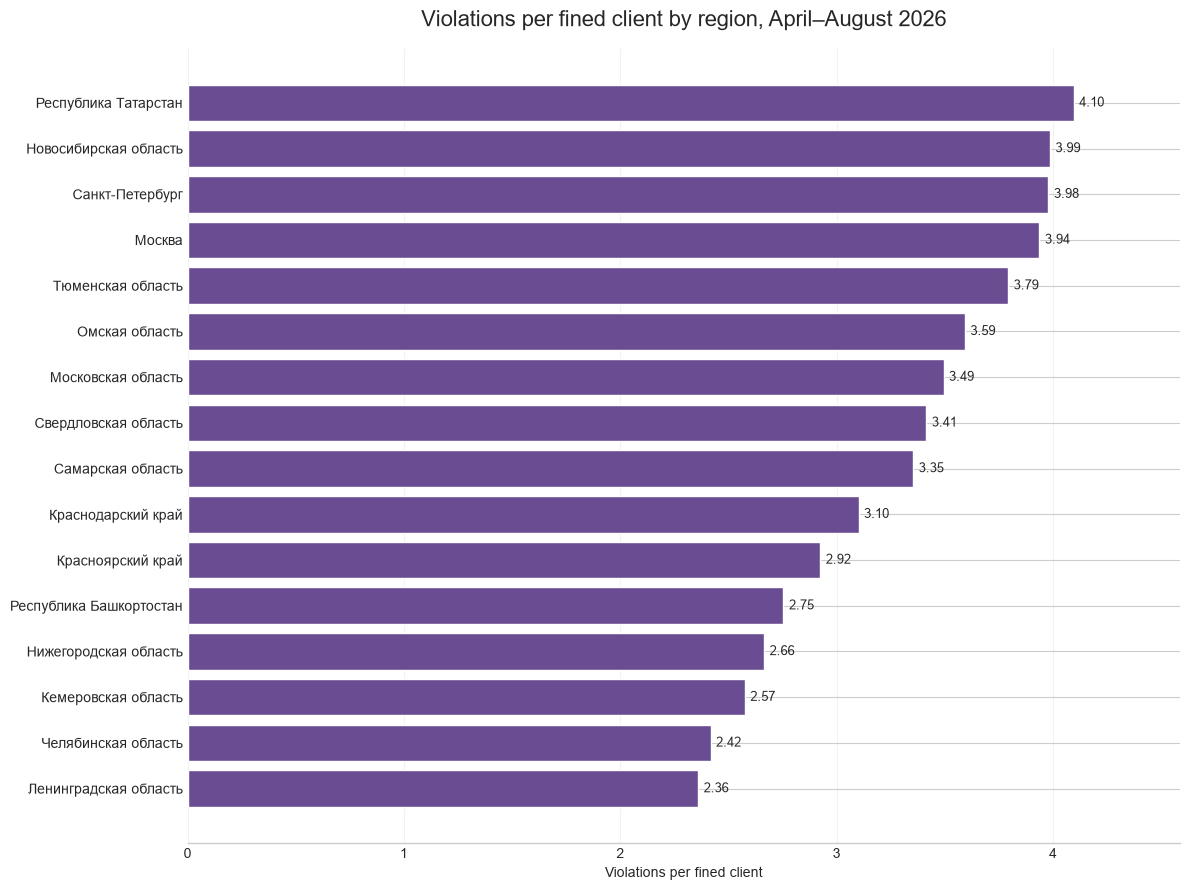

Saved: data\processed\violations_per_fined_client_by_region.png


In [42]:
ranking = violations_per_client_total.sort_values("violations_per_fined_client")
fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(ranking["region_name"], ranking["violations_per_fined_client"],
               color="#6A4C93")
ax.bar_label(bars, labels=[f"{value:.2f}" for value in ranking["violations_per_fined_client"]],
             padding=4, fontsize=9)
ax.set_title("Violations per fined client by region, April–August 2026", fontsize=16, pad=16)
ax.set_xlabel("Violations per fined client")
ax.set_ylabel("")
ax.set_xlim(0, ranking["violations_per_fined_client"].max() * 1.12)
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right", "left"]].set_visible(False)
fig.tight_layout()
violations_per_client_total_chart = OUTPUT_DIR / "violations_per_fined_client_by_region.png"
fig.savefig(violations_per_client_total_chart, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved:", violations_per_client_total_chart)

## Mathematical model: fuel price and violation frequency

**Hypothesis.** Higher regional fuel prices reduce violations per client because driving becomes more selective: fewer discretionary trips remain, while necessary trips dominate.

The model uses a `region × month` panel for April–August 2026. Fines are assigned by the client's registration region so that numerator and denominator refer to the same population. Late entry is handled through client-day exposure: fines before `subscription_creation_date` are excluded, and the count-model offset is `log(client_month_exposure)`. Region fixed effects control for permanent regional differences, month fixed effects control for common shocks, and standard errors are clustered by region.

In [43]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

client_subscription = clients[["client_id", "subscription_creation_date"]].copy()
client_subscription["subscription_creation_date"] = pd.to_datetime(
    client_subscription["subscription_creation_date"], errors="coerce"
)
client_subscription = client_subscription.groupby("client_id", as_index=False).agg(
    subscription_creation_date=("subscription_creation_date", "min")
)
registration_regions = client_region.rename(
    columns={"region_name": "registration_region_name"}
).merge(client_subscription, on="client_id", validate="one_to_one")
fines_by_registration = fines.merge(
    registration_regions[["client_id", "region_code", "registration_region_name",
                          "subscription_creation_date"]],
    on="client_id", how="inner", validate="many_to_one",
)
assert len(fines_by_registration) == len(fines)
fines_before_subscription = (
    fines_by_registration["bill_offence_date"]
    < fines_by_registration["subscription_creation_date"]
)
eligible_fines = fines_by_registration.loc[~fines_before_subscription].copy()
eligible_fines["month"] = eligible_fines["bill_offence_date"].dt.to_period("M").astype(str)
registered_fines_monthly = (
    eligible_fines[eligible_fines["month"].between("2026-04", "2026-08")]
    .groupby(["month", "region_code"], as_index=False)
    .agg(fine_count=("bill_id", "nunique"), fined_clients=("client_id", "nunique"))
)
observation_months = pd.period_range("2026-04", "2026-08", freq="M")
exposure_parts = []
for month in observation_months:
    month_start, month_end = month.start_time, month.end_time.normalize()
    part = registration_regions.copy()
    part["month"] = str(month)
    observed_start = part["subscription_creation_date"].clip(lower=month_start)
    part["exposure_days"] = ((month_end - observed_start).dt.days + 1).clip(
        lower=0, upper=month.days_in_month
    )
    exposure_parts.append(part)
client_month_exposure = pd.concat(exposure_parts, ignore_index=True)
regional_exposure = client_month_exposure.groupby(
    ["month", "region_code", "registration_region_name"], as_index=False
).agg(
    client_days=("exposure_days", "sum"),
    clients_observed=("exposure_days", lambda values: values.gt(0).sum()),
)
days_in_month = {str(month): month.days_in_month for month in observation_months}
regional_exposure["client_month_exposure"] = (
    regional_exposure["client_days"]
    / regional_exposure["month"].map(days_in_month)
)

hypothesis_panel = region_monthly_charts.rename(columns={
    "sale_month": "month", "sale_count": "fuel_sale_count",
}).merge(
    registered_fines_monthly, on=["month", "region_code"], how="left",
    validate="one_to_one",
).merge(
    regional_exposure, on=["month", "region_code"], how="left",
    validate="one_to_one",
)
hypothesis_panel[["fine_count", "fined_clients"]] = (
    hypothesis_panel[["fine_count", "fined_clients"]].fillna(0)
)
hypothesis_panel["violations_per_1000_clients"] = (
    1000 * hypothesis_panel["fine_count"] / hypothesis_panel["client_month_exposure"]
)
hypothesis_panel["sold_volume_per_client"] = (
    hypothesis_panel["sold_volume_liters"] / hypothesis_panel["client_month_exposure"]
)
assert len(hypothesis_panel) == 16 * 5
assert hypothesis_panel[["fine_count", "client_month_exposure",
                         "weighted_price_rub_per_liter"]].notna().all().all()
hypothesis_panel.to_csv(OUTPUT_DIR / "hypothesis_region_month_panel.csv", index=False)
hypothesis_panel.head()

,month,region_code,region_name,fuel_sale_count,active_clients,sold_volume_liters,sales_revenue_rub,weighted_price_rub_per_liter,average_sale_liters,average_sale_rub,month_name,fine_count,fined_clients,registration_region_name,client_days,clients_observed,client_month_exposure,violations_per_1000_clients,sold_volume_per_client
0,2026-04,02,Республика Башкортостан,1028,225,37145.18,2.302519e+06,61.987025,36.133444,2239.804672,Апрель,156,70,Республика Башкортостан,8588,288,286.266667,544.946437,129.757266
1,2026-04,16,Республика Татарстан,6267,1480,223109.87,1.435955e+07,64.360886,35.600745,2291.295502,Апрель,888,472,Республика Татарстан,53122,1791,1770.733333,501.487143,125.998571
2,2026-04,23,Краснодарский край,2355,553,92248.91,6.398417e+06,69.360359,39.171512,2716.950099,Апрель,344,174,Краснодарский край,20163,684,672.100000,511.828597,137.254739
3,2026-04,24,Красноярский край,1987,507,72772.62,4.968674e+06,68.276698,36.624368,2500.590936,Апрель,224,117,Красноярский край,21852,738,728.400000,307.523339,99.907496
4,2026-04,42,Кемеровская область,2036,504,74427.80,4.932383e+06,66.270706,36.555894,2422.584881,Апрель,168,102,Кемеровская область,19290,653,643.000000,261.275272,115.750855


### Estimation and robustness

Poisson is the baseline count model. Because the variance may exceed the Poisson mean, Negative Binomial is the main robustness model. OLS checks the result using violations per 1,000 clients. A separate OLS model tests the proposed mechanism: whether sold fuel volume per registered client falls when price rises.

In [44]:
count_formula = (
    "fine_count ~ weighted_price_rub_per_liter + C(region_code) + C(month)"
)
cluster_options = {
    "groups": hypothesis_panel["region_code"], "use_correction": True,
}
exposure_offset = np.log(hypothesis_panel["client_month_exposure"])

poisson_model = smf.glm(
    count_formula, data=hypothesis_panel, family=sm.families.Poisson(),
    offset=exposure_offset,
).fit(cov_type="cluster", cov_kwds=cluster_options)
negative_binomial_model = smf.negativebinomial(
    count_formula, data=hypothesis_panel, offset=exposure_offset,
).fit(
    disp=False, method="bfgs", maxiter=3000,
    cov_type="cluster", cov_kwds=cluster_options,
)
rate_ols_model = smf.ols(
    "violations_per_1000_clients ~ weighted_price_rub_per_liter + "
    "C(region_code) + C(month)", data=hypothesis_panel,
).fit(cov_type="cluster", cov_kwds=cluster_options)
mechanism_model = smf.ols(
    "sold_volume_per_client ~ weighted_price_rub_per_liter + "
    "C(region_code) + C(month)", data=hypothesis_panel,
).fit(cov_type="cluster", cov_kwds=cluster_options)

price_term = "weighted_price_rub_per_liter"
def model_result_row(name, model, outcome, count_model=False):
    beta = model.params[price_term]
    low, high = model.conf_int().loc[price_term]
    row = {
        "model": name, "outcome": outcome, "observations": int(model.nobs),
        "price_coefficient": beta, "std_error": model.bse[price_term],
        "p_value": model.pvalues[price_term], "ci_95_low": low, "ci_95_high": high,
    }
    if count_model:
        row.update({
            "effect_percent_per_1_rub": 100 * (np.exp(beta) - 1),
            "effect_percent_ci_low": 100 * (np.exp(low) - 1),
            "effect_percent_ci_high": 100 * (np.exp(high) - 1),
        })
    return row

hypothesis_model_results = pd.DataFrame([
    model_result_row("Poisson FE", poisson_model, "fine_count", True),
    model_result_row("Negative Binomial FE", negative_binomial_model, "fine_count", True),
    model_result_row("OLS FE", rate_ols_model, "violations_per_1000_clients"),
    model_result_row("Mechanism OLS FE", mechanism_model, "sold_volume_per_client"),
])
poisson_dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid
hypothesis_model_results["poisson_dispersion"] = np.nan
hypothesis_model_results.loc[
    hypothesis_model_results["model"].eq("Poisson FE"), "poisson_dispersion"
] = poisson_dispersion
hypothesis_model_results.to_csv(OUTPUT_DIR / "hypothesis_model_results.csv", index=False)
(OUTPUT_DIR / "hypothesis_poisson_summary.txt").write_text(
    poisson_model.summary().as_text(), encoding="utf-8"
)
(OUTPUT_DIR / "hypothesis_negative_binomial_summary.txt").write_text(
    negative_binomial_model.summary().as_text(), encoding="utf-8"
)
hypothesis_model_results.round(4)

C:\Users\dedde\PycharmProjects\HakDANO\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,model,outcome,observations,price_coefficient,std_error,p_value,ci_95_low,ci_95_high,effect_percent_per_1_rub,effect_percent_ci_low,effect_percent_ci_high,poisson_dispersion
0,Poisson FE,fine_count,80,0.0141,0.0408,0.7290,-0.0658,0.0941,1.4239,-6.3728,9.8698,29.0435
1,Negative Binomial FE,fine_count,80,0.0183,0.0187,0.3282,-0.0184,0.0550,1.8490,-1.8234,5.6588,NaN
2,OLS FE,violations_per_1000_clients,80,7.8321,8.4281,0.3527,-8.6867,24.3509,NaN,NaN,NaN,NaN
3,Mechanism OLS FE,sold_volume_per_client,80,-4.9741,1.2287,0.0001,-7.3823,-2.5659,NaN,NaN,NaN,NaN


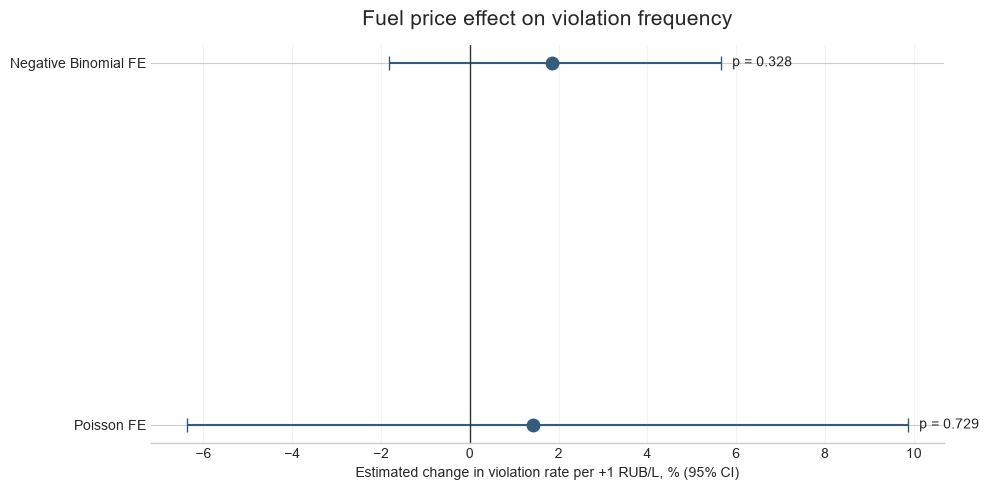

Saved: data\processed\hypothesis_fuel_price_model.png


In [45]:
count_results = hypothesis_model_results[
    hypothesis_model_results["model"].isin(["Poisson FE", "Negative Binomial FE"])
].copy()
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(count_results))
effects = count_results["effect_percent_per_1_rub"].to_numpy()
lower = effects - count_results["effect_percent_ci_low"].to_numpy()
upper = count_results["effect_percent_ci_high"].to_numpy() - effects
ax.errorbar(effects, y, xerr=np.vstack([lower, upper]), fmt="o", markersize=9,
            capsize=5, color="#355C7D", ecolor="#355C7D")
ax.axvline(0, color="#333333", linewidth=1)
ax.set_yticks(y, count_results["model"])
ax.set_xlabel("Estimated change in violation rate per +1 RUB/L, % (95% CI)")
ax.set_title("Fuel price effect on violation frequency", fontsize=15, pad=14)
for i, (_, row) in enumerate(count_results.iterrows()):
    ax.annotate(f"p = {row['p_value']:.3f}", (row["effect_percent_ci_high"], i),
                xytext=(8, 0), textcoords="offset points", va="center")
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right", "left"]].set_visible(False)
fig.tight_layout()
model_chart = OUTPUT_DIR / "hypothesis_fuel_price_model.png"
fig.savefig(model_chart, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved:", model_chart)

In [46]:
nb_row = hypothesis_model_results.loc[
    hypothesis_model_results["model"].eq("Negative Binomial FE")
].iloc[0]
mechanism_row = hypothesis_model_results.loc[
    hypothesis_model_results["model"].eq("Mechanism OLS FE")
].iloc[0]
hypothesis_supported = (
    nb_row["price_coefficient"] < 0 and nb_row["p_value"] < 0.05
)
print("Fines excluded because they occurred before subscription:",
      int(fines_before_subscription.sum()))
print("Poisson dispersion:", round(poisson_dispersion, 2))
print("Negative Binomial price effect, % per +1 RUB/L:",
      round(nb_row["effect_percent_per_1_rub"], 3))
print("Negative Binomial p-value:", round(nb_row["p_value"], 4))
print("Mechanism: liters/client coefficient per +1 RUB/L:",
      round(mechanism_row["price_coefficient"], 3),
      "p-value:", round(mechanism_row["p_value"], 4))
print("Hypothesis supported at 5% level:", hypothesis_supported)
print("Interpretation: the mechanism of lower fuel volume is present, but the data do not "
      "show a statistically significant reduction in violation frequency as fuel prices rise.")

Fines excluded because they occurred before subscription: 1548
Poisson dispersion: 29.04
Negative Binomial price effect, % per +1 RUB/L: 1.849
Negative Binomial p-value: 0.3282
Mechanism: liters/client coefficient per +1 RUB/L: -4.974 p-value: 0.0001
Hypothesis supported at 5% level: False
Interpretation: the mechanism of lower fuel volume is present, but the data do not show a statistically significant reduction in violation frequency as fuel prices rise.
